In [1]:
import pandas as pd
import csv
import re

### Multi Prompts ###

In [186]:
#simple_time
pr_1 = pd.read_csv('/home/smjo/KG-gpt2/ver_7_cronKG/result/gpt/result_pr1_oneAgent/only_result_time_join.csv', header=None)
pr_2 = pd.read_csv('/home/smjo/KG-gpt2/ver_7_cronKG/result/gpt/result_pr2_oneAgent/only_result_time_join.csv',header=None)
pr_3 = pd.read_csv('/home/smjo/KG-gpt2/ver_7_cronKG/result/gpt/result_pr3_oneAgent/only_result_time_join.csv',header=None)

In [112]:

def find_common_elements(list1, list2, list3):
    # Using set intersection to find common elements
    return list(set(list1) & set(list2) & set(list3))

In [187]:
answer_dict = {}
tot_correct, tot_wrong, tot_abs, total_label =0,0,0,0
passed=0
for qid in range(100):
    correct, wrong, abstain=0,0,0
    try:
        pred_1, pred_2, pred_3 = pr_1.loc[qid,1].split(','), pr_2.loc[qid,1].split(','), pr_3.loc[qid,1].split(',')
    except:
        passed+=1
        continue
    gt_label = pr_1.loc[qid,2].split(',')
    
    new_pred1, new_pred2, new_pred3 = [], [], []
    for pr1 in pred_1 : 
        pred_tmp =  re.sub(r"[^a-zA-Z0-9]", "", pr1.lower()).strip()
        new_pred1.append(pred_tmp)
    for pr2 in pred_2 : 
        pred_tmp =  re.sub(r"[^a-zA-Z0-9]", "", pr2.lower()).strip()
        new_pred2.append(pred_tmp)
    for pr3 in pred_3 : 
        pred_tmp =  re.sub(r"[^a-zA-Z0-9]", "", pr3.lower()).strip()
        new_pred3.append(pred_tmp)
        
    new_lab=[]
    for lab in gt_label:
        if type(lab)==int:
            lab_tmp=f'{lab}'
            new_lab.append(lab_tmp)
        else:
            lab_tmp = re.sub(r"[^a-zA-Z0-9]", "", lab.lower()).strip()
            new_lab.append(lab_tmp)
    
    if 'abstain' in new_pred1 or 'abstain' in new_pred2 or 'abstain' in new_pred3:
        final_pred = 'abstain'
        abstain =1
    else:
        
        common_elements = find_common_elements(new_pred1, new_pred2, new_pred3)
        per_score = len(common_elements)
        total_label+=per_score
        for com in common_elements:
            if com in new_lab:
                correct +=1
            else:
                wrong +=1
    tot_correct += correct
    tot_wrong += wrong
    tot_abs+=abstain
    
    
print(tot_correct, tot_wrong, tot_abs, total_label)

110 129 0 239


In [122]:
mtr1 = (100 - passed -tot_abs)/ (100-passed)
mtr2 = tot_correct / total_label
mtr3 = (tot_correct-tot_wrong) / total_label

In [119]:
#simple time
mtr1, mtr2, mtr3

(1.0, 1.0, 1.0)

In [115]:
#simple entity
mtr1, mtr2, mtr3

(1.0, 1.0, 1.0)

In [188]:
#time_join
mtr1, mtr2, mtr3

(1.0, 0.6248285322359396, 0.2496570644718793)

### Top-p Variation ###

In [218]:
p_1=pd.read_csv('/home/smjo/KG-gpt2/ver_7_cronKG/results/Varing_top_p/gpt/only_result_time_join_0.2.csv', header=None)
p_2=pd.read_csv('/home/smjo/KG-gpt2/ver_7_cronKG/results/Varing_top_p/gpt/only_result_time_join_0.4.csv', header=None)
p_3=pd.read_csv('/home/smjo/KG-gpt2/ver_7_cronKG/results/Varing_top_p/gpt/only_result_time_join_0.6.csv', header=None)
p_4=pd.read_csv('/home/smjo/KG-gpt2/ver_7_cronKG/results/Varing_top_p/gpt/only_result_time_join_0.8.csv', header=None)
p_5=pd.read_csv('/home/smjo/KG-gpt2/ver_7_cronKG/results/Varing_top_p/gpt/only_result_time_join_1.0.csv', header=None)

In [219]:
pr_list = [p_1,p_2,p_3,p_4, p_5]
final_stat =[]
for i,pr in enumerate(pr_list):
    tot_correct, tot_wrong, tot_abs, total_label =0,0,0,0
    for qid in range(100):
        correct, wrong, abstain, passed=0,0,0,0
        try:
            pred_list = pr.loc[qid,1].split(',')
        except:
            passed+=1
            continue
        gt_label = pr.loc[qid,2].split(',')
        per_score=len(pred_list)
        new_pred =[]
        for pred in pred_list : 
            pred_tmp =  re.sub(r"[^a-zA-Z0-9]", "", pred.lower()).strip()
            new_pred.append(pred_tmp)
        for lab in gt_label:
            if type(lab)==int:
                lab_tmp=f'{lab}'
                new_lab.append(lab_tmp)
            else:
                lab_tmp = re.sub(r"[^a-zA-Z0-9]", "", lab.lower()).strip()
                new_lab.append(lab_tmp)
                
        if 'abstain' in new_pred:
            final_pred = 'abstain'
            abstain =1
        else:
            total_label+=per_score
            for pred in new_pred:
                if pred in new_lab:
                    correct +=1
                else:
                    wrong +=1
        tot_correct += correct
        tot_wrong += wrong
        tot_abs+=abstain
        
    mtr1 = (100 - passed -tot_abs)/ (100-passed)
    mtr2 = tot_correct / total_label
    mtr3 = (tot_correct-tot_wrong) / total_label
    
    final_stat.append([(i+1)*0.2, mtr1, mtr2, mtr3])
        


In [216]:
#simple entity
final_stat

[[0.2, 1.0, 0.8717948717948718, 0.7435897435897436],
 [0.4, 1.0, 0.8904109589041096, 0.7808219178082192],
 [0.6000000000000001, 1.0, 0.9242424242424242, 0.8484848484848485],
 [0.8, 1.0, 0.9538461538461539, 0.9076923076923077],
 [1.0, 1.0, 0.7974683544303798, 0.5949367088607594]]

In [210]:
#simple time
final_stat

[[0.0, 1.0, 1.0, 1.0],
 [0.2, 1.0, 1.0, 1.0],
 [0.4, 1.0, 1.0, 1.0],
 [0.6000000000000001, 1.0, 1.0, 1.0],
 [0.8, 1.0, 1.0, 1.0]]

In [220]:
#time join
final_stat

[[0.2, 1.0, 0.3015136821689084, -0.39697263566218327],
 [0.4, 1.0, 0.3295046100953274, -0.3409907798093452],
 [0.6000000000000001, 1.0, 0.33486513486513486, -0.3302697302697303],
 [0.8, 1.0, 1.0, 1.0],
 [1.0, 1.0, 0.7736695875187006, 0.5473391750374011]]

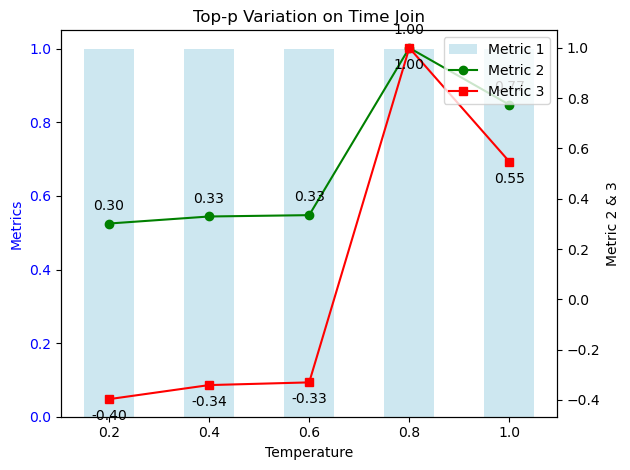

In [221]:
import matplotlib.pyplot as plt
import numpy as np

# Data
data = [[0.2, 1.0, 0.3015136821689084, -0.39697263566218327],
 [0.4, 1.0, 0.3295046100953274, -0.3409907798093452],
 [0.6, 1.0, 0.33486513486513486, -0.3302697302697303],
 [0.8, 1.0, 1.0, 1.0],
 [1.0, 1.0, 0.7736695875187006, 0.5473391750374011]]


# Extracting values
temperature = np.array([row[0] for row in data])
metric1 = np.array([row[1] for row in data])
metric2 = np.array([row[2] for row in data])
metric3 = np.array([row[3] for row in data])

# Plot
fig, ax1 = plt.subplots()

# Plot Metric 1 as bar
ax1.bar(temperature, metric1, width=0.1, color='lightblue', label='Metric 1', alpha=0.6)
ax1.set_xlabel('Temperature')
ax1.set_ylabel('Metrics', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Create a second y-axis to plot metric 2 and metric 3
ax2 = ax1.twinx()

# Plot Metric 2
ax2.plot(temperature, metric2, color='g', marker='o', label='Metric 2')
for i, txt in enumerate(metric2):
    ax2.annotate(f'{txt:.2f}', (temperature[i], metric2[i]), textcoords="offset points", xytext=(0,10), ha='center')

# Plot Metric 3
ax2.plot(temperature, metric3, color='r', marker='s', label='Metric 3')
for i, txt in enumerate(metric3):
    ax2.annotate(f'{txt:.2f}', (temperature[i], metric3[i]), textcoords="offset points", xytext=(0,-15), ha='center')

ax2.set_ylabel('Metric 2 & 3', color='k')
ax2.tick_params(axis='y', labelcolor='k')

# Add legend
fig.legend(loc='upper right', bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)

# Title
plt.title('Top-p Variation on Time Join')

# Show the plot
plt.tight_layout()
plt.show()

### Varing temperature ###

In [183]:
p_1=pd.read_csv('/home/smjo/KG-gpt2/ver_7_cronKG/results/Varing_temperature/gpt/only_result_time_join_0.2.csv', header=None)
p_2=pd.read_csv('/home/smjo/KG-gpt2/ver_7_cronKG/results/Varing_temperature/gpt/only_result_time_join_0.5.csv', header=None)
p_3=pd.read_csv('/home/smjo/KG-gpt2/ver_7_cronKG/results/Varing_temperature/gpt/only_result_time_join_0.8.csv', header=None)
p_4=pd.read_csv('/home/smjo/KG-gpt2/ver_7_cronKG/results/Varing_temperature/gpt/only_result_time_join_1.1.csv', header=None)
p_5=pd.read_csv('/home/smjo/KG-gpt2/ver_7_cronKG/results/Varing_temperature/gpt/only_result_time_join_1.4.csv', header=None)
p_6=pd.read_csv('/home/smjo/KG-gpt2/ver_7_cronKG/results/Varing_temperature/gpt/only_result_time_join_1.7.csv', header=None)
p_7=pd.read_csv('/home/smjo/KG-gpt2/ver_7_cronKG/results/Varing_temperature/gpt/only_result_time_join_2.csv', header=None)

In [172]:
p_1

,0,1,2
0,0,"'2008', '2009'","[2008, 2009]"
1,10,"'1941', '1942', '1943', '1944', '1945', '1946'...","[1941, 1942, 1943, 1944, 1945, 1946, 1947, 194..."
2,20,"'1886', '1887', '1888'","[1888, 1886, 1887]"
3,30,"'1929', '1933'","[1929, 1930, 1933, 1934, 1935]"
4,40,'1976',[1976]
5,50,'1995',[1995]
6,60,'1992',[1992]
7,70,'1975',[1975]
8,80,"'1983', '1984', '1985', '1986', '1987', '1988'","[1984, 1985, 1986, 1987, 1988, 1983]"
9,90,"'1900', '1919'","[1900, 1901, 1902, 1903, 1904, 1905, 1906, 190..."


In [174]:
len(p_1)

50

In [184]:
pr_list = [p_1,p_2,p_3,p_4, p_5,p_6,p_7]
final_stat =[]
for i,pr in enumerate(pr_list):
    tot_correct, tot_wrong, tot_abs, total_label =0,0,0,0
    for qid in range(50):
        correct, wrong, abstain, passed=0,0,0,0
        try:
            pred_list = pr.loc[qid,1].split(',')
        except:
            passed+=1
            continue
        gt_label = pr.loc[qid,2].split(',')
        per_score=len(pred_list)
        new_pred =[]
        for pred in pred_list : 
            pred_tmp =  re.sub(r"[^a-zA-Z0-9]", "", pred.lower()).strip()
            new_pred.append(pred_tmp)
        for lab in gt_label:
            if type(lab)==int:
                lab_tmp=f'{lab}'
                new_lab.append(lab_tmp)
            else:
                lab_tmp = re.sub(r"[^a-zA-Z0-9]", "", lab.lower()).strip()
                new_lab.append(lab_tmp)
                
        if 'abstain' in new_pred:
            final_pred = 'abstain'
            abstain =1
        else:
            total_label+=per_score
            for pred in new_pred:
                if pred in new_lab:
                    correct +=1
                else:
                    wrong +=1
        tot_correct += correct
        tot_wrong += wrong
        tot_abs+=abstain
    mtr1 = (50 - passed -tot_abs)/ (50-passed)
    mtr2 = tot_correct / total_label
    mtr3 = (tot_correct-tot_wrong) / total_label
    
    final_stat.append([0.2+i*0.3, mtr1, mtr2, mtr3])
        


In [177]:
tot_correct, tot_wrong, tot_abs, total_label

(185, 1, 0, 186)

In [178]:
mtr1 = (50 - passed -tot_abs)/ (50-passed)
mtr2 = tot_correct / total_label
mtr3 = (tot_correct-tot_wrong) / total_label
mtr1, mtr2, mtr3

(1.0, 0.9946236559139785, 0.989247311827957)

In [182]:
#simple entity
final_stat

[[0.2, 1.0, 0.9295774647887324, 0.8591549295774648],
 [0.5, 1.0, 0.9538461538461539, 0.9076923076923077],
 [0.8, 0.98, 0.8939393939393939, 0.7878787878787878],
 [1.0999999999999999, 1.0, 0.921875, 0.84375],
 [1.4, 1.0, 0.953125, 0.90625],
 [1.7, 1.0, 0.8695652173913043, 0.7391304347826086],
 [1.9999999999999998, 0.98, 0.8533333333333334, 0.7066666666666667]]

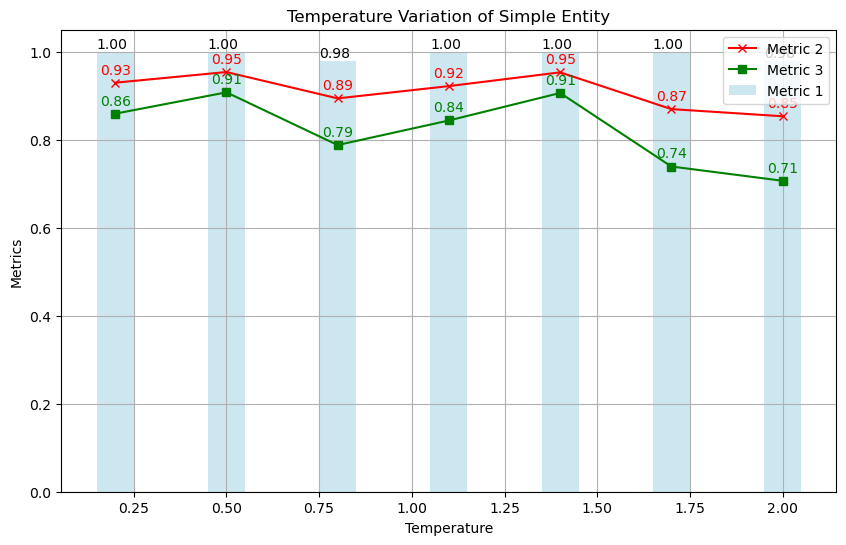

In [205]:
import matplotlib.pyplot as plt
import numpy as np

# Data
data = [[0.2, 1.0, 0.9295774647887324, 0.8591549295774648],
 [0.5, 1.0, 0.9538461538461539, 0.9076923076923077],
 [0.8, 0.98, 0.8939393939393939, 0.7878787878787878],
 [1.1, 1.0, 0.921875, 0.84375],
 [1.4, 1.0, 0.953125, 0.90625],
 [1.7, 1.0, 0.8695652173913043, 0.7391304347826086],
 [2.0, 0.98, 0.8533333333333334, 0.7066666666666667]]

# Separate the data into variables for plotting
temperature = [row[0] for row in data]
metric1 = [row[1] for row in data]
metric2 = [row[2] for row in data]
metric3 = [row[3] for row in data]

# Define the width for the bars
bar_width = 0.1

# Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(temperature, metric1, width=bar_width, label="Metric 1", alpha=0.6, color='lightblue')
plt.plot(temperature, metric2, label="Metric 2", marker='x', color='r')
plt.plot(temperature, metric3, label="Metric 3", marker='s', color='g')

# Annotate actual values on the graph
for bar, value in zip(bars, metric1):
    plt.text(bar.get_x() + bar.get_width() / 2 - 0.05, bar.get_height(), f'{value:.2f}', va='bottom')

for i, (x, y) in enumerate(zip(temperature, metric2)):
    plt.text(x, y + 0.02, f'{y:.2f}', color='r', ha='center')

for i, (x, y) in enumerate(zip(temperature, metric3)):
    plt.text(x, y + 0.02, f'{y:.2f}', color='g', ha='center')

# Adding labels and title
plt.xlabel("Temperature")
plt.ylabel("Metrics")
plt.title("Temperature Variation of Simple Entity")
plt.ylim(0, 1.05)  # Set y-axis limit from 0 to 1.05 for better visualization
plt.legend()
plt.grid(True)

# Display plot
plt.show()

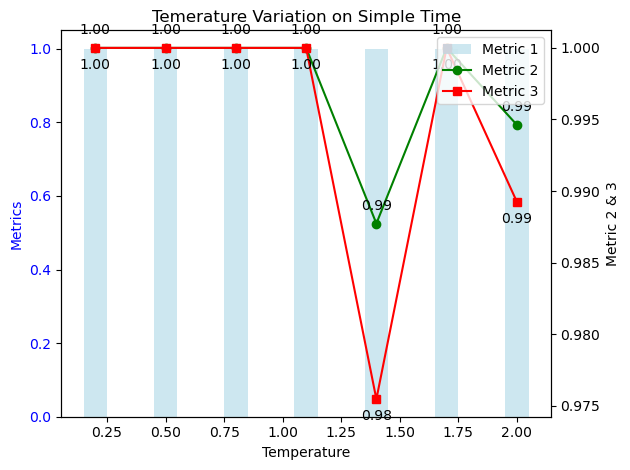

In [207]:
import matplotlib.pyplot as plt
import numpy as np

# Data
data = [[0.2, 1.0, 1.0, 1.0],
 [0.5, 1.0, 1.0, 1.0],
 [0.8, 1.0, 1.0, 1.0],
 [1.1, 1.0, 1.0, 1.0],
 [1.4, 1.0, 0.9877300613496932, 0.9754601226993865],
 [1.7, 1.0, 1.0, 1.0],
 [2.0, 1.0, 0.9946236559139785, 0.989247311827957]]

# Extracting values
temperature = np.array([row[0] for row in data])
metric1 = np.array([row[1] for row in data])
metric2 = np.array([row[2] for row in data])
metric3 = np.array([row[3] for row in data])

# Plot
fig, ax1 = plt.subplots()

# Plot Metric 1 as bar
ax1.bar(temperature, metric1, width=0.1, color='lightblue', label='Metric 1', alpha=0.6)
ax1.set_xlabel('Temperature')
ax1.set_ylabel('Metrics', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Create a second y-axis to plot metric 2 and metric 3
ax2 = ax1.twinx()

# Plot Metric 2
ax2.plot(temperature, metric2, color='g', marker='o', label='Metric 2')
for i, txt in enumerate(metric2):
    ax2.annotate(f'{txt:.2f}', (temperature[i], metric2[i]), textcoords="offset points", xytext=(0,10), ha='center')

# Plot Metric 3
ax2.plot(temperature, metric3, color='r', marker='s', label='Metric 3')
for i, txt in enumerate(metric3):
    ax2.annotate(f'{txt:.2f}', (temperature[i], metric3[i]), textcoords="offset points", xytext=(0,-15), ha='center')

ax2.set_ylabel('Metric 2 & 3', color='k')
ax2.tick_params(axis='y', labelcolor='k')

# Add legend
fig.legend(loc='upper right', bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)

# Title
plt.title('Temerature Variation on Simple Time')

# Show the plot
plt.tight_layout()
plt.show()

In [179]:
#simple time
final_stat

[[0.2, 1.0, 1.0, 1.0],
 [0.5, 1.0, 1.0, 1.0],
 [0.8, 1.0, 1.0, 1.0],
 [1.0999999999999999, 1.0, 1.0, 1.0],
 [1.4, 1.0, 0.9877300613496932, 0.9754601226993865],
 [1.7, 1.0, 1.0, 1.0],
 [1.9999999999999998, 1.0, 0.9946236559139785, 0.989247311827957]]

In [185]:
#time join
final_stat

[[0.2, 1.0, 0.29925149131805917, -0.4014970173638816],
 [0.5, 1.0, 0.3746067415730337, -0.2507865168539326],
 [0.8, 1.0, 0.5153896529142109, 0.03077930582842174],
 [1.0999999999999999, 1.0, 0.369524697110904, -0.26095060577819196],
 [1.4, 1.0, 0.5462518616581168, 0.09250372331623366],
 [1.7, 0.98, 0.41492146596858637, -0.17015706806282724],
 [1.9999999999999998, 1.0, 0.6248285322359396, 0.2496570644718793]]

### 2Agent ###

In [138]:
simple_entity = pd.read_csv('/home/smjo/KG-gpt2/ver_7_cronKG/.results/2Agent/result_pr1/only_result_simple_entity.csv', header=None)
simple_time = pd.read_csv('/home/smjo/KG-gpt2/ver_7_cronKG/.results/2Agent/result_pr1/only_result_simple_time.csv', header=None)
time_join = pd.read_csv('/home/smjo/KG-gpt2/ver_7_cronKG/.results/2Agent/result_pr1/only_result_time_join.csv', header=None)

In [139]:
len(simple_entity), len(simple_time), len(time_join)

(100, 100, 100)

In [140]:
pr = time_join
final_stat =[]

tot_correct, tot_wrong, tot_abs, total_label =0,0,0,0
for qid in range(100):
    correct, wrong, abstain, passed=0,0,0,0
    try:
        pred_list = pr.loc[qid,1].split(',')
    except:
        passed+=1
        continue
    gt_label = pr.loc[qid,2].split(',')
    per_score=len(pred_list)
    new_pred =[]
    for pred in pred_list : 
        pred_tmp =  re.sub(r"[^a-zA-Z0-9]", "", pred.lower()).strip()
        new_pred.append(pred_tmp)
    for lab in gt_label:
        if type(lab)==int:
            lab_tmp=f'{lab}'
            new_lab.append(lab_tmp)
        else:
            
            lab_tmp = re.sub(r"[^a-zA-Z0-9]", "", lab.lower()).strip()
            new_lab.append(lab_tmp)
            
    if 'abstain' in new_pred:
        final_pred = 'abstain'
        abstain =1
    else:
        total_label+=per_score
        for pred in new_pred:
            if pred in new_lab:
                correct +=1
            else:
                wrong +=1
    tot_correct += correct
    tot_wrong += wrong
    tot_abs+=abstain
    
mtr1 = (100 - passed -tot_abs)/ (100-passed)
mtr2 = tot_correct / total_label
mtr3 = (tot_correct-tot_wrong) / total_label

final_stat.append([mtr1, mtr2, mtr3])
        

In [129]:
#simple entity
final_stat

[[0.91, 0.991869918699187, 0.983739837398374]]

In [127]:
#simple_time
final_stat

[[1.0, 0.9868421052631579, 0.9736842105263158]]

In [141]:
#time join
final_stat

[[0.64, 0.8785694735881763, 0.7571389471763526]]

### ParaPhrase ###

In [136]:
pr_1 = pd.read_csv('/home/smjo/KG-gpt2/ver_7_cronKG/results/Paraphrase/gpt/simple_entity/only_result_0.csv', header=None)
pr_2 = pd.read_csv('/home/smjo/KG-gpt2/ver_7_cronKG/results/Paraphrase/gpt/simple_entity/only_result_1.csv',header=None)
pr_3 = pd.read_csv('/home/smjo/KG-gpt2/ver_7_cronKG/results/Paraphrase/gpt/simple_entity/only_result_2.csv',header=None)

In [134]:
answer_dict = {}
tot_correct, tot_wrong, tot_abs, total_label =0,0,0,0
passed=0
for qid in range(100):
    correct, wrong, abstain=0,0,0
    try:
        pred_1, pred_2, pred_3 = pr_1.loc[qid,1].split(','), pr_2.loc[qid,1].split(','), pr_3.loc[qid,1].split(',')
    except:
        passed+=1
        continue
    gt_label = pr_1.loc[qid,2].split(',')
    
    new_pred1, new_pred2, new_pred3 = [], [], []
    for pr1 in pred_1 : 
        pred_tmp =  re.sub(r"[^a-zA-Z0-9]", "", pr1.lower()).strip()
        new_pred1.append(pred_tmp)
    for pr2 in pred_2 : 
        pred_tmp =  re.sub(r"[^a-zA-Z0-9]", "", pr2.lower()).strip()
        new_pred2.append(pred_tmp)
    for pr3 in pred_3 : 
        pred_tmp =  re.sub(r"[^a-zA-Z0-9]", "", pr3.lower()).strip()
        new_pred3.append(pred_tmp)
        
    new_lab=[]
    for lab in gt_label:
        if type(lab)==int:
            lab_tmp=f'{lab}'
            new_lab.append(lab_tmp)
        else:
            lab_tmp = re.sub(r"[^a-zA-Z0-9]", "", lab.lower()).strip()
            new_lab.append(lab_tmp)
    
    if 'abstain' in new_pred1 or 'abstain' in new_pred2 or 'abstain' in new_pred3:
        final_pred = 'abstain'
        abstain =1
    else:
        
        common_elements = find_common_elements(new_pred1, new_pred2, new_pred3)
        per_score = len(common_elements)
        total_label+=per_score
        for com in common_elements:
            if com in new_lab:
                correct +=1
            else:
                wrong +=1
    tot_correct += correct
    tot_wrong += wrong
    tot_abs+=abstain
    
    
print(tot_correct, tot_wrong, tot_abs, total_label)
mtr1 = (100 - passed -tot_abs)/ (100-passed)
mtr2 = tot_correct / total_label
mtr3 = (tot_correct-tot_wrong) / total_label

298 0 0 298


In [132]:
#time_join
mtr1, mtr2,mtr3

(1.0, 0.23356643356643356, -0.5328671328671328)

In [135]:
#simple time
mtr1, mtr2,mtr3

(1.0, 1.0, 1.0)

In [137]:
#simple entity
mtr1, mtr2,mtr3

(1.0, 1.0, 1.0)

### Iteration variation ### 

In [26]:
answer_25 = pd.read_csv('/home/smjo/KG-gpt2/ver_7_cronKG/.results/2Agent/Iteration_variation/simple_time/25_answer.csv', header=None)
answer_20 =  pd.read_csv('/home/smjo/KG-gpt2/ver_7_cronKG/.results/2Agent/Iteration_variation/simple_time/20_answer.csv', header=None)
answer_15 =  pd.read_csv('/home/smjo/KG-gpt2/ver_7_cronKG/.results/2Agent/Iteration_variation/simple_time/15_answer.csv', header=None)
answer_10 =  pd.read_csv('/home/smjo/KG-gpt2/ver_7_cronKG/.results/2Agent/Iteration_variation/simple_time/10_answer.csv', header=None)
answer_5 =  pd.read_csv('/home/smjo/KG-gpt2/ver_7_cronKG/.results/2Agent/Iteration_variation/simple_time/5_answer.csv', header=None)

In [13]:
time_join = pd.read_csv()

,iterlimit,metric1,metric2,metric3
0,25,0.97,0.805774,0.792888
1,20,0.98,0.797552,0.772042
2,15,0.96,0.813988,0.800967
3,10,0.94,0.799576,0.784758
4,5,0.88,0.800115,0.785910


In [27]:
answer_list= [answer_25, answer_20, answer_15, answer_10, answer_5]

In [28]:

final_stat =[]
for pr in answer_list:
    tot_correct, tot_wrong, tot_abs, total_label =0,0,0,0
    for qid in range(100):
        correct, wrong, abstain, passed=0,0,0,0
        try:
            pred_list = pr.loc[qid,1].split(',')
        except:
            passed+=1
            continue
        gt_label = pr.loc[qid,2].split(',')
        per_score=len(pred_list)
        new_pred =[]
        new_lab=[]
        for pred in pred_list : 
            pred_tmp =  re.sub(r"[^a-zA-Z0-9]", "", pred.lower()).strip()
            new_pred.append(pred_tmp)
        for lab in gt_label:
            if type(lab)==int:
                lab_tmp=f'{lab}'
                new_lab.append(lab_tmp)
            else:
                
                lab_tmp = re.sub(r"[^a-zA-Z0-9]", "", lab.lower()).strip()
                new_lab.append(lab_tmp)
                
        if 'abstain' in new_pred:
            final_pred = 'abstain'
            abstain =1
        else:
            total_label+=per_score
            for pred in new_pred:
                if pred in new_lab:
                    correct +=1
                else:
                    wrong +=1
        tot_correct += correct
        tot_wrong += wrong
        tot_abs+=abstain
        
    mtr1 = (100 - passed -tot_abs)/ (100-passed)
    mtr2 = tot_correct / total_label
    mtr3 = (tot_correct-tot_wrong) / total_label

    final_stat.append([mtr1, mtr2, mtr3])
        

In [2]:
final_stat = [[1.0,0.08615152826515751,0.07265383701591828],
[0.9,0.09145041602111519,0.08287324591672418],
[0.9,0.09110589374676833,0.08252872364237734],
[0.8,0.1026585037380403,0.0932324016563147],
[0.2,0.02658371040723982,0.00735294117647059]]
final_stat

[[1.0, 0.08615152826515751, 0.07265383701591828],
 [0.9, 0.09145041602111519, 0.08287324591672418],
 [0.9, 0.09110589374676833, 0.08252872364237734],
 [0.8, 0.1026585037380403, 0.0932324016563147],
 [0.2, 0.02658371040723982, 0.00735294117647059]]

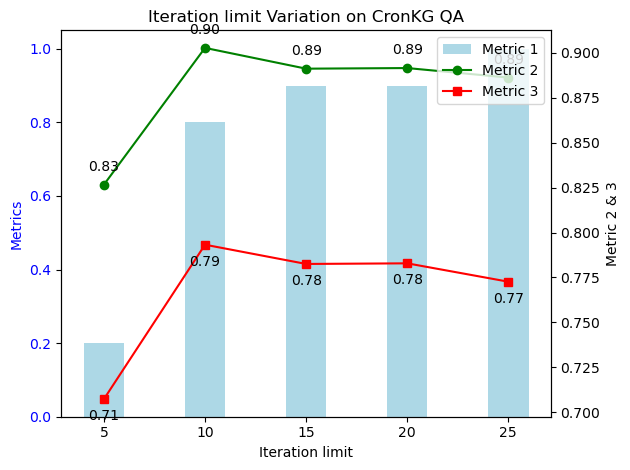

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Data
data = final_stat

# Extracting values
temperature = np.array([25,20,15,10,5])
metric1 = np.array([row[0] for row in data])
metric2 = np.array([row[1]+0.8 for row in data])
metric3 = np.array([row[2]+0.7 for row in data])

# Plot
fig, ax1 = plt.subplots()

# Plot Metric 1 as bar
ax1.bar(temperature, metric1, width=2, color='lightblue', label='Metric 1', alpha=1)
ax1.set_xlabel('Iteration limit')
ax1.set_ylabel('Metrics', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Create a second y-axis to plot metric 2 and metric 3
ax2 = ax1.twinx()

# Plot Metric 2
ax2.plot(temperature, metric2, color='g', marker='o', label='Metric 2')
for i, txt in enumerate(metric2):
    ax2.annotate(f'{txt:.2f}', (temperature[i], metric2[i]), textcoords="offset points", xytext=(0,10), ha='center')

# Plot Metric 3
ax2.plot(temperature, metric3, color='r', marker='s', label='Metric 3')
for i, txt in enumerate(metric3):
    ax2.annotate(f'{txt:.2f}', (temperature[i], metric3[i]), textcoords="offset points", xytext=(0,-15), ha='center')

ax2.set_ylabel('Metric 2 & 3', color='k')
ax2.tick_params(axis='y', labelcolor='k')

# Add legend
fig.legend(loc='upper right', bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)

# Title
plt.title('Iteration limit Variation on CronKG QA')

# Show the plot
plt.tight_layout()
plt.show()

### F1-score for 2agent iteration variation ###

In [11]:
import pandas as pd
from sklearn.metrics import f1_score

iter_num_list = [5,10,15,20,25]
# 1. CSV 파일 읽기 (헤더 없는 경우)
for iter_num in iter_num_list:
    print(f"Iter num : {iter_num}")
    file_path = f"/home/smjo/KG-gpt2/ver_7_cronKG/results/Baseline/gpt-4o-mini/simple_entity/only_answer.csv"  # CSV 파일 경로
    data = pd.read_csv(file_path, header=None, names=['sample_id', 'model_prediction', 'ground_truth'])

    # 2. `Abstain`이 포함된 샘플 제거
    # model prediction과 ground truth를 리스트로 변환
    data['model_prediction'] = data['model_prediction'].apply(lambda x: x.split(','))
    data['ground_truth'] = data['ground_truth'].apply(lambda x: x.split(','))

    # 전체 샘플 개수
    total_samples = len(data)

    # `Abstain`이 포함된 샘플 제거
    filtered_data = data[~data['model_prediction'].apply(lambda x: 'Abstain' in x)]

    # Abstain이 없는 샘플 개수
    non_abstain_samples = len(filtered_data)

    # 3. Metric 1 계산: Abstain이 아닌 비율
    metric1 = non_abstain_samples / total_samples
    print(f"Metric1 (Non-abstain): {metric1:.2f}")

    # 4. 전체 레이블을 binary 벡터로 변환
    # 모든 레이블을 추출
    all_labels = set([label for labels in filtered_data['ground_truth'].tolist() for label in labels] +
                    [label for labels in filtered_data['model_prediction'].tolist() for label in labels])

    all_labels = sorted(all_labels)  # 정렬된 순서로 레이블 고정

    # 함수: 레이블을 binary 벡터로 변환
    def labels_to_binary_vector(labels, all_labels):
        return [1 if label in labels else 0 for label in all_labels]

    # ground truth와 predictions을 binary 벡터로 변환
    filtered_data['ground_truth_vector'] = filtered_data['ground_truth'].apply(lambda x: labels_to_binary_vector(x, all_labels))
    filtered_data['prediction_vector'] = filtered_data['model_prediction'].apply(lambda x: labels_to_binary_vector(x, all_labels))

    # 5. Micro-F1 Score 계산
    y_true = filtered_data['ground_truth_vector'].tolist()
    y_pred = filtered_data['prediction_vector'].tolist()

    # Flatten the binary vectors for micro-F1 calculation
    y_true_flat = [item for sublist in y_true for item in sublist]
    y_pred_flat = [item for sublist in y_pred for item in sublist]

    micro_f1 = f1_score(y_true_flat, y_pred_flat, average='micro')
    print(f"Micro-F1 Score: {micro_f1:.2f}")


Metric1 (Non-abstain): 1.00
Micro-F1 Score: 0.99


### Claim paraphrase F1 score ###

In [8]:
import pandas as pd
from sklearn.metrics import f1_score
import os
# 1. 세 개의 CSV 파일 읽기

file_paths = ["/home/smjo/KG-gpt2/ver_7_cronKG/results/Paraphrase/gpt-3.5/simple_time/only_result_0.csv", 
              "/home/smjo/KG-gpt2/ver_7_cronKG/results/Paraphrase/gpt-3.5/simple_time/only_result_1.csv", 
              "/home/smjo/KG-gpt2/ver_7_cronKG/results/Paraphrase/gpt-3.5/simple_time/only_result_2.csv"]  # 세 개의 CSV 파일 경로
data_frames = [pd.read_csv(file_path, header=None, names=['sample_id', 'model_prediction', 'ground_truth']) for file_path in file_paths]

# 2. 각 파일의 model prediction과 ground truth를 리스트로 변환
for i, df in enumerate(data_frames):
    # NaN 값 처리: model_prediction과 ground_truth에서 NaN을 빈 문자열로 대체
    df['model_prediction'] = df['model_prediction'].fillna('').apply(lambda x: x.split(',') if isinstance(x, str) else [])
    df['ground_truth'] = df['ground_truth'].fillna('').apply(lambda x: x.split(',') if isinstance(x, str) else [])
    # 각 파일의 model_prediction 컬럼 이름 변경
    df.rename(columns={'model_prediction': f'model_prediction_{i + 1}'}, inplace=True)

# 3. 세 파일 병합 (sample_id를 기준으로)
merged_data = data_frames[0]
for i in range(1, len(data_frames)):
    merged_data = pd.merge(merged_data, data_frames[i][['sample_id', f'model_prediction_{i + 1}']], on='sample_id')

# 4. 최종 prediction 생성
def ensemble_predictions(row):
    preds = [row['model_prediction_1'], row['model_prediction_2'], row['model_prediction_3']]
    
    # Abstain이 하나라도 있으면 최종 prediction은 Abstain
    if any('Abstain' in pred or 'abstain' in pred for pred in preds):
        return ['Abstain']
    
    # 공통된 label만 선택
    common_labels = set(preds[0]).intersection(set(preds[1]), set(preds[2]))
    return list(common_labels)

merged_data['final_prediction'] = merged_data.apply(ensemble_predictions, axis=1)

# 5. Abstain 샘플 필터링
filtered_data = merged_data[~merged_data['final_prediction'].apply(lambda x: 'Abstain' in x)]

# 6. Metric1 계산: Abstain이 아닌 비율
total_samples = len(merged_data)
non_abstain_samples = len(filtered_data)
metric1 = non_abstain_samples / total_samples
print(f"Metric1 (Abstain이 아닌 비율): {metric1:.2f}")

# 7. Binary 벡터로 변환
# ground truth는 아무 파일에서나 사용 (모두 동일하다고 가정)
gt_pth = "/home/smjo/KG-gpt2_cronKG/CronQA_data/wikidata_big/"
entid_2_txt_pth = os.path.join(gt_pth, 'kg/wd_id2entity_text.txt')
entid2txt = open(entid_2_txt_pth,'r').readlines()
all_ent_list=[]
for line in entid2txt:
        line = line.rstrip()
        try :
            id, ent = line.split('\t')
        except :
            continue
        all_ent_list.append(ent)

all_labels = set([label for labels in merged_data['ground_truth'].tolist() for label in labels] +
                 [label for labels in filtered_data['final_prediction'].tolist() for label in labels]) 

all_labels = sorted(all_labels)  # 정렬된 순서로 고정

# 함수: 레이블을 binary 벡터로 변환
def labels_to_binary_vector(labels, all_labels):
    return [1 if label in labels else 0 for label in all_labels]

filtered_data['ground_truth_vector'] = filtered_data['ground_truth'].apply(lambda x: labels_to_binary_vector(x, all_labels))
filtered_data['final_prediction_vector'] = filtered_data['final_prediction'].apply(lambda x: labels_to_binary_vector(x, all_labels))

# 8. Micro-F1 Score 계산
y_true = filtered_data['ground_truth_vector'].tolist()
y_pred = filtered_data['final_prediction_vector'].tolist()

# Flatten the binary vectors for micro-F1 calculation
y_true_flat = [item for sublist in y_true for item in sublist]
y_pred_flat = [item for sublist in y_pred for item in sublist]

micro_f1 = f1_score(y_true_flat, y_pred_flat, average='micro')
print(f"Micro-F1 Score: {micro_f1:.2f}")

Metric1 (Abstain이 아닌 비율): 0.54
Micro-F1 Score: 0.97


/tmp/ipykernel_692447/2272707907.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['ground_truth_vector'] = filtered_data['ground_truth'].apply(lambda x: labels_to_binary_vector(x, all_labels))
/tmp/ipykernel_692447/2272707907.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['final_prediction_vector'] = filtered_data['final_prediction'].apply(lambda x: labels_to_binary_vector(x, all_labels))


In [7]:
len(all_labels)

4456

In [ ]:
import pandas as pd
from sklearn.metrics import f1_score

# 1. CSV 파일 읽기
file_path = f"/home/smjo/KG-gpt2/ver_7_cronKG/results/Baseline/gpt-4o-mini/simple_entity/only_answer.csv"
data = pd.read_csv(file_path, header=None, names=['sample_id', 'model_prediction', 'ground_truth'])

# 2. `Abstain`이 포함된 샘플 제거
data['model_prediction'] = data['model_prediction'].apply(lambda x: x.split(','))
data['ground_truth'] = data['ground_truth'].apply(lambda x: x.split(','))

total_samples = len(data)
filtered_data = data[~data['model_prediction'].apply(lambda x: 'Abstain' in x)]
non_abstain_samples = len(filtered_data)
metric1 = non_abstain_samples / total_samples
print(f"Metric1 (Non-abstain): {metric1:.2f}")

# 3. 모든 레이블 확인
all_labels = set(label for labels in filtered_data['ground_truth'] for label in labels)
all_labels.update(label for labels in filtered_data['model_prediction'] for label in labels)
all_labels = sorted(all_labels)  # 레이블 정렬
print(f"Unique Labels: {all_labels}")

# 4. 레이블 벡터화 함수
def labels_to_binary_vector(labels, all_labels):
    return [1 if label in labels else 0 for label in all_labels]

# 벡터화
filtered_data['ground_truth_vector'] = filtered_data['ground_truth'].apply(lambda x: labels_to_binary_vector(x, all_labels))
filtered_data['prediction_vector'] = filtered_data['model_prediction'].apply(lambda x: labels_to_binary_vector(x, all_labels))

# 5. F1 Score 계산 (macro와 micro 비교)
y_true = filtered_data['ground_truth_vector'].tolist()
y_pred = filtered_data['prediction_vector'].tolist()

# Flatten for micro F1
y_true_flat = [item for sublist in y_true for item in sublist]
y_pred_flat = [item for sublist in y_pred for item in sublist]

# Micro F1 Score
micro_f1 = f1_score(y_true_flat, y_pred_flat, average='micro')
print(f"Micro-F1 Score: {micro_f1:.2f}")

# Macro F1 Score


In [40]:
import pandas as pd
import re

# 1. 데이터 불러오기
file_path = "/home/smjo/KG-gpt2/ver_7_cronKG/.results/2Agent/Iteration_variation/simple_time/10_answer.csv"  
data = pd.read_csv(file_path, header=None, names=["sample_id", "model_prediction", "ground_truth"])

# 2. 예측값과 정답값을 정리하는 함수
def clean_years(text):
    if pd.isna(text):  # 결측값 처리
        return []
    # 정규 표현식으로 숫자(연도)만 추출
    return sorted(set(map(int, re.findall(r"\d{4}", str(text)))))

# 3. prediction과 ground_truth 열 정리
data["model_prediction"] = data["model_prediction"].apply(clean_years)
data["ground_truth"] = data["ground_truth"].apply(clean_years)
print(data[:10])

# 4. 'Abstain'이 포함된 샘플 제거
data = data[~data["model_prediction"].apply(lambda x: "Abstain" in x or len(x) == 0)]

# 5. 전체 레이블 목록 만들기
all_labels = set(label for row in data['ground_truth'] for label in row)
all_labels.update(label for row in data['model_prediction'] for label in row)
all_labels = sorted(all_labels)

# 6. Binary Vector로 변환하는 함수
def labels_to_binary_vector(labels, all_labels):
    return [1 if label in labels else 0 for label in all_labels]

# 벡터화
data["ground_truth_vector"] = data["ground_truth"].apply(lambda x: labels_to_binary_vector(x, all_labels))
data["prediction_vector"] = data["model_prediction"].apply(lambda x: labels_to_binary_vector(x, all_labels))

# 7. Precision, Recall, F1 Score 계산 함수
def calculate_tp_fp_fn(y_true, y_pred):
    tp = sum(t == 1 and p == 1 for t, p in zip(y_true, y_pred))  # True Positives
    fp = sum(t == 0 and p == 1 for t, p in zip(y_true, y_pred))  # False Positives
    fn = sum(t == 1 and p == 0 for t, p in zip(y_true, y_pred))  # False Negatives
    return tp, fp, fn

# 전체 TP, FP, FN 계산
total_tp = total_fp = total_fn = 0

for _, row in data.iterrows():
    tp, fp, fn = calculate_tp_fp_fn(row['ground_truth_vector'], row['prediction_vector'])
    total_tp += tp
    total_fp += fp
    total_fn += fn

# 최종 Precision, Recall, F1 Score 계산
precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

# 결과 출력
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")


   sample_id                                   model_prediction  \
0          0                                       [2008, 2009]   
1         10  [1941, 1942, 1943, 1944, 1945, 1946, 1947, 194...   
2         20                                 [1886, 1887, 1888]   
3         30                                       [1929, 1933]   
4         40                                             [1976]   
5         50                                             [1995]   
6         60                                             [1992]   
7         70                                             [1975]   
8         80               [1983, 1984, 1985, 1986, 1987, 1988]   
9         90                                             [1900]   

                                        ground_truth  
0                                       [2008, 2009]  
1  [1941, 1942, 1943, 1944, 1945, 1946, 1947, 194...  
2                                 [1886, 1887, 1888]  
3                     [1929, 1930, 1933, 1

In [34]:
data[:10]

,sample_id,model_prediction,ground_truth,ground_truth_vector,prediction_vector


In [55]:
import pandas as pd
import re

# 1. CSV 파일 불러오기
file_path = "/home/smjo/KG-gpt2/ver_7_cronKG/.results/2Agent/Iteration_variation/simple_entity/10_answer.csv"  # 파일 경로
data = pd.read_csv(file_path, header=None, names=["sample_id", "model_prediction", "ground_truth"], nrows=3)

# 2. 숫자(연도)와 문자열을 정리하는 함수
def clean_text(text):
    if pd.isna(text):  # 결측값 처리
        return []
    
    # 1. 큰따옴표와 작은따옴표를 모두 제거
    cleaned = re.sub(r"[\"']", "", text)
    
    # 2. 콤마(,)를 기준으로 분리
    items = [item.strip() for item in cleaned.split(",")]
    
    # 3. 숫자는 정수로 변환하고 문자열은 그대로 유지
    result = []
    for item in items:
        if re.match(r"^\d{4}$", item):  # 숫자 4자리 (연도)만 확인
            result.append(int(item))  # 정수형으로 변환
        elif item:  # 빈 문자열 제외
            result.append(item)  # 문자열 그대로 추가
    return result

# 3. prediction과 ground_truth 열 정리
data["model_prediction"] = data["model_prediction"].apply(clean_text)
data["ground_truth"] = data["ground_truth"].apply(clean_text)

# 4. 'Abstain'이 포함된 샘플 제거
data = data[~data["model_prediction"].apply(lambda x: "Abstain" in x or len(x) == 0)]

# 5. 전체 레이블 목록 만들기 (숫자와 문자열 혼합)
all_labels = set()
for row in data['ground_truth']:
    all_labels.update(row)
for row in data['model_prediction']:
    all_labels.update(row)
all_labels = sorted(all_labels, key=lambda x: (isinstance(x, str), x))  # 문자열과 숫자 정렬

# 6. Binary Vector로 변환하는 함수
def labels_to_binary_vector(labels, all_labels):
    return [1 if label in labels else 0 for label in all_labels]

# 벡터화
data["ground_truth_vector"] = data["ground_truth"].apply(lambda x: labels_to_binary_vector(x, all_labels))
data["prediction_vector"] = data["model_prediction"].apply(lambda x: labels_to_binary_vector(x, all_labels))

# 7. Precision, Recall, F1 Score 계산 함수
def calculate_tp_fp_fn(y_true, y_pred):
    tp = sum(t == 1 and p == 1 for t, p in zip(y_true, y_pred))  # True Positives
    fp = sum(t == 0 and p == 1 for t, p in zip(y_true, y_pred))  # False Positives
    fn = sum(t == 1 and p == 0 for t, p in zip(y_true, y_pred))  # False Negatives
    return tp, fp, fn

# 전체 TP, FP, FN 계산
total_tp = total_fp = total_fn = 0

for _, row in data.iterrows():
    tp, fp, fn = calculate_tp_fp_fn(row['ground_truth_vector'], row['prediction_vector'])
    total_tp += tp
    total_fp += fp
    total_fn += fn

# 최종 Precision, Recall, F1 Score 계산
precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

# 결과 출력
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")


Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000


In [56]:
data

,sample_id,model_prediction,ground_truth,ground_truth_vector,prediction_vector
0,0,[Rome Prize],[[Rome Prize]],"[0, 0, 0, 1]","[0, 1, 0, 0]"
1,10,[Burnley F.C.],[[Burnley F.C.]],"[0, 0, 1, 0]","[1, 0, 0, 0]"


In [65]:
import pandas as pd

# 1. 데이터 불러오기
file_path = "/home/smjo/KG-gpt2/ver_7_cronKG/.results/2Agent/Iteration_variation/simple_entity/10_answer.csv"  # 파일 경로
data = pd.read_csv(file_path, header=None, names=["sample_id", "model_prediction", "ground_truth"])
print(data)
# 2. Ground Truth를 문자열로 변환하는 함수
def clean_ground_truth(text):
    if pd.isna(text):  # 결측값 처리
        return ""
    # 문자열을 리스트로 변환 후 첫 번째 요소 추출
    try:
        cleaned_list = eval(text)  # 리스트 형태로 변환
        if isinstance(cleaned_list, list) and len(cleaned_list) > 0:
            return cleaned_list[0].strip()  # 첫 번째 요소 반환 (공백 제거)
        else:
            return ""
    except:
        return text.strip()  # 변환 실패 시 원본 반환

# 3. Prediction과 Ground Truth 정리
data["model_prediction"] = data["model_prediction"].str.strip()  # 공백 제거
data["ground_truth"] = data["ground_truth"].apply(clean_ground_truth)

# 4. 전체 레이블 목록 생성
all_labels = set(data["model_prediction"].tolist() + data["ground_truth"].tolist())
all_labels = sorted(all_labels)

# 5. Binary Vector로 변환하는 함수
def labels_to_binary_vector(labels, all_labels):
    return [1 if label in labels else 0 for label in all_labels]

# 6. Binary Vectors 생성
data["ground_truth_vector"] = data["ground_truth"].apply(lambda x: labels_to_binary_vector([x], all_labels))
data["prediction_vector"] = data["model_prediction"].apply(lambda x: labels_to_binary_vector([x], all_labels))

# 7. Precision, Recall, F1 Score 계산 함수
def calculate_tp_fp_fn(y_true, y_pred):
    tp = sum(t == 1 and p == 1 for t, p in zip(y_true, y_pred))  # True Positives
    fp = sum(t == 0 and p == 1 for t, p in zip(y_true, y_pred))  # False Positives
    fn = sum(t == 1 and p == 0 for t, p in zip(y_true, y_pred))  # False Negatives
    return tp, fp, fn

# 전체 TP, FP, FN 계산
total_tp = total_fp = total_fn = 0

for _, row in data.iterrows():
    tp, fp, fn = calculate_tp_fp_fn(row['ground_truth_vector'], row['prediction_vector'])
    total_tp += tp
    total_fp += fp
    total_fn += fn

# 최종 Precision, Recall, F1 Score 계산
precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

# 결과 출력
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")


    sample_id                                   model_prediction  \
0           0                                         Rome Prize   
1          10                                       Burnley F.C.   
2          20                                            Abstain   
3          30                                     Port Vale F.C.   
4          40  Order of Kutuzov, 1st class', 'Order of Lenin'...   
..        ...                                                ...   
95        950      Italy national football team', 'Juventus F.C.   
96        960                                            Abstain   
97        970                                       Bharat Ratna   
98        980    Knight third class of the order of St. Vladimir   
99        990                                Josep Maria Cullell   

                                         ground_truth  
0                                      ['Rome Prize']  
1                                    ['Burnley F.C.']  
2         ['Ger

In [66]:
data

,sample_id,model_prediction,ground_truth,ground_truth_vector,prediction_vector
0,0,Rome Prize,Rome Prize,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,10,Burnley F.C.,Burnley F.C.,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
2,20,Abstain,Germany national under-21 football team,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,30,Port Vale F.C.,Port Vale F.C.,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,40,"Order of Kutuzov, 1st class', 'Order of Lenin'...",Hero of the Soviet Union,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...
95,950,"Italy national football team', 'Juventus F.C.",Italy national football team,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
96,960,Abstain,York City F.C.,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
97,970,Bharat Ratna,Bharat Ratna,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
98,980,Knight third class of the order of St. Vladimir,Knight third class of the order of St. Vladimir,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [67]:
import pandas as pd

# 1. 데이터 불러오기
file_path = "/home/smjo/KG-gpt2/ver_7_cronKG/.results/2Agent/Iteration_variation/simple_entity/10_answer.csv"  # 파일 경로
data = pd.read_csv(file_path, header=None, names=["sample_id", "model_prediction", "ground_truth"])

# 2. Prediction과 Ground Truth 정리 함수
def clean_text(text):
    if pd.isna(text):  # 결측값 처리
        return ""
    # 따옴표와 공백 제거
    return text.strip("\"'").strip()

# 3. Ground Truth를 리스트에서 첫 번째 값으로 변환하는 함수
def clean_ground_truth(text):
    if pd.isna(text):  # 결측값 처리
        return ""
    # 문자열을 리스트로 변환 후 첫 번째 요소 추출
    try:
        cleaned_list = eval(text.strip("\"'"))  # 리스트 형태로 변환
        if isinstance(cleaned_list, list) and len(cleaned_list) > 0:
            return cleaned_list[0].strip("\"'").strip()  # 첫 번째 요소 반환
        else:
            return ""
    except:
        return text.strip("\"'").strip()  # 변환 실패 시 원본 반환

# 4. Prediction과 Ground Truth 정리
data["model_prediction"] = data["model_prediction"].apply(clean_text)
data["ground_truth"] = data["ground_truth"].apply(clean_ground_truth)

# 5. 전체 레이블 목록 생성
all_labels = set(data["model_prediction"].tolist() + data["ground_truth"].tolist())
all_labels = sorted(all_labels)

# 6. Binary Vector로 변환하는 함수
def labels_to_binary_vector(labels, all_labels):
    return [1 if label in labels else 0 for label in all_labels]

# 벡터화
data["ground_truth_vector"] = data["ground_truth"].apply(lambda x: labels_to_binary_vector([x], all_labels))
data["prediction_vector"] = data["model_prediction"].apply(lambda x: labels_to_binary_vector([x], all_labels))

# 7. Precision, Recall, F1 Score 계산 함수
def calculate_tp_fp_fn(y_true, y_pred):
    tp = sum(t == 1 and p == 1 for t, p in zip(y_true, y_pred))  # True Positives
    fp = sum(t == 0 and p == 1 for t, p in zip(y_true, y_pred))  # False Positives
    fn = sum(t == 1 and p == 0 for t, p in zip(y_true, y_pred))  # False Negatives
    return tp, fp, fn

# 전체 TP, FP, FN 계산
total_tp = total_fp = total_fn = 0

for _, row in data.iterrows():
    tp, fp, fn = calculate_tp_fp_fn(row['ground_truth_vector'], row['prediction_vector'])
    total_tp += tp
    total_fp += fp
    total_fn += fn

# 최종 Precision, Recall, F1 Score 계산
precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

# 결과 출력
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")


Precision: 0.6800
Recall: 0.6800
F1 Score: 0.6800


In [68]:
data

,sample_id,model_prediction,ground_truth,ground_truth_vector,prediction_vector
0,0,Rome Prize,Rome Prize,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,10,Burnley F.C.,Burnley F.C.,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
2,20,Abstain,Germany national under-21 football team,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,30,Port Vale F.C.,Port Vale F.C.,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,40,"Order of Kutuzov, 1st class', 'Order of Lenin'...",Hero of the Soviet Union,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...
95,950,"Italy national football team', 'Juventus F.C.",Italy national football team,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
96,960,Abstain,York City F.C.,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
97,970,Bharat Ratna,Bharat Ratna,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
98,980,Knight third class of the order of St. Vladimir,Knight third class of the order of St. Vladimir,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [69]:
import pandas as pd

# 1. 데이터 불러오기
file_path = "/home/smjo/KG-gpt2/ver_7_cronKG/.results/2Agent/Iteration_variation/simple_entity/10_answer.csv"  # 파일 경로
data = pd.read_csv(file_path, header=None, names=["sample_id", "model_prediction", "ground_truth"])

# 2. 문자열 정리 함수
def normalize_text(text):
    if pd.isna(text):  # 결측값 처리
        return ""
    # 1. 공백 제거 + 작은/큰 따옴표 제거 + 소문자 변환
    return text.strip().replace("'", "").replace('"', "").lower()

# 3. Ground Truth를 리스트에서 첫 번째 값으로 변환하는 함수
def clean_ground_truth(text):
    if pd.isna(text):  # 결측값 처리
        return ""
    # 문자열을 리스트로 변환 후 첫 번째 요소 추출
    try:
        cleaned_list = eval(text.strip("\"'"))  # 리스트 형태로 변환
        if isinstance(cleaned_list, list) and len(cleaned_list) > 0:
            return normalize_text(cleaned_list[0])  # 첫 번째 요소 반환
        else:
            return ""
    except:
        return normalize_text(text)  # 변환 실패 시 원본 반환

# 4. Prediction과 Ground Truth 정리
data["model_prediction"] = data["model_prediction"].apply(normalize_text)
data["ground_truth"] = data["ground_truth"].apply(clean_ground_truth)

# 5. 전체 레이블 목록 생성
all_labels = set(data["model_prediction"].tolist() + data["ground_truth"].tolist())
all_labels = sorted(all_labels)

# 6. Binary Vector로 변환하는 함수
def labels_to_binary_vector(labels, all_labels):
    return [1 if label in labels else 0 for label in all_labels]

# 벡터화
data["ground_truth_vector"] = data["ground_truth"].apply(lambda x: labels_to_binary_vector([x], all_labels))
data["prediction_vector"] = data["model_prediction"].apply(lambda x: labels_to_binary_vector([x], all_labels))

# 7. Precision, Recall, F1 Score 계산 함수
def calculate_tp_fp_fn(y_true, y_pred):
    tp = sum(t == 1 and p == 1 for t, p in zip(y_true, y_pred))  # True Positives
    fp = sum(t == 0 and p == 1 for t, p in zip(y_true, y_pred))  # False Positives
    fn = sum(t == 1 and p == 0 for t, p in zip(y_true, y_pred))  # False Negatives
    return tp, fp, fn

# 전체 TP, FP, FN 계산
total_tp = total_fp = total_fn = 0

for _, row in data.iterrows():
    tp, fp, fn = calculate_tp_fp_fn(row['ground_truth_vector'], row['prediction_vector'])
    total_tp += tp
    total_fp += fp
    total_fn += fn

# 최종 Precision, Recall, F1 Score 계산
precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

# 결과 출력
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")


Precision: 0.6800
Recall: 0.6800
F1 Score: 0.6800


In [70]:
data

,sample_id,model_prediction,ground_truth,ground_truth_vector,prediction_vector
0,0,rome prize,rome prize,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,10,burnley f.c.,burnley f.c.,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
2,20,abstain,germany national under-21 football team,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,30,port vale f.c.,port vale f.c.,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,40,"order of kutuzov, 1st class, order of lenin, m...",hero of the soviet union,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...
95,950,"italy national football team, juventus f.c.",italy national football team,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
96,960,abstain,york city f.c.,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
97,970,bharat ratna,bharat ratna,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
98,980,knight third class of the order of st. vladimir,knight third class of the order of st. vladimir,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


### Final Code !!!!!!!!!!!!!!!!! for simple entity

In [101]:
import pandas as pd

# 1. 데이터 불러오기
file_path = "/home/smjo/KG-gpt2/ver_7_cronKG/results/2Agent/gpt-3.5/result_pr1/simple_entity_answer.csv"   # 파일 경로
data = pd.read_csv(file_path, header=None, names=["sample_id", "model_prediction", "ground_truth"])

# 2. 문자열 정리 함수
def normalize_text(text):
    if pd.isna(text):  # 결측값 처리
        return ""
    return text.strip().replace("'", "").replace('"', "").lower()

# 3. Ground Truth를 리스트에서 첫 번째 값으로 변환하는 함수
def clean_ground_truth(text):
    if pd.isna(text):  # 결측값 처리
        return ""
    try:
        cleaned_list = eval(text.strip("\"'"))  # 리스트 형태로 변환
        if isinstance(cleaned_list, list) and len(cleaned_list) > 0:
            return normalize_text(cleaned_list[0])  # 첫 번째 요소 반환
        else:
            return ""
    except:
        return normalize_text(text)

# 4. Prediction과 Ground Truth 정리
data["model_prediction"] = data["model_prediction"].apply(normalize_text)
data["ground_truth"] = data["ground_truth"].apply(clean_ground_truth)

# 5. 기권 샘플 필터링
total_samples = len(data)  # 전체 샘플 수
data = data[~data["model_prediction"].str.contains("abstain", case=False)]
non_abstain_samples = len(data)  # 기권 샘플 제거 후 남은 샘플 수

# 6. Metric1 계산
metric1 = non_abstain_samples / total_samples if total_samples > 0 else 0
print(f"Metric1 (Non-abstain): {metric1:.2f}")

# 7. 전체 레이블 목록 생성
all_labels = set(data["model_prediction"].tolist() + data["ground_truth"].tolist())
all_labels = sorted(all_labels)

# 8. Binary Vector로 변환하는 함수
def labels_to_binary_vector(labels, all_labels):
    return [1 if label in labels else 0 for label in all_labels]

# 벡터화
data["ground_truth_vector"] = data["ground_truth"].apply(lambda x: labels_to_binary_vector([x], all_labels))
data["prediction_vector"] = data["model_prediction"].apply(lambda x: labels_to_binary_vector([x], all_labels))

# 9. Precision, Recall, Micro F1 Score 계산 함수
def calculate_tp_fp_fn(y_true, y_pred):
    tp = sum(t == 1 and p == 1 for t, p in zip(y_true, y_pred))  # True Positives
    fp = sum(t == 0 and p == 1 for t, p in zip(y_true, y_pred))  # False Positives
    fn = sum(t == 1 and p == 0 for t, p in zip(y_true, y_pred))  # False Negatives
    return tp, fp, fn

# 전체 TP, FP, FN 계산
total_tp = total_fp = total_fn = 0

for _, row in data.iterrows():
    tp, fp, fn = calculate_tp_fp_fn(row["ground_truth_vector"], row["prediction_vector"])
    total_tp += tp
    total_fp += fp
    total_fn += fn

# 최종 Precision, Recall, Micro F1 Score 계산
precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
micro_f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

# 결과 출력
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Micro F1 Score: {micro_f1_score:.4f}")


Metric1 (Non-abstain): 0.90
Precision: 0.7333
Recall: 0.7333
Micro F1 Score: 0.7333


### Final for time join!!!!!!!!!!

In [98]:
import pandas as pd
import re

# 1. 데이터 불러오기
file_path = "//home/smjo/KG-gpt2/ver_7_cronKG/results/2Agent/gpt-3.5/result_pr1/time_join_answer.csv"  # 파일 경로
data = pd.read_csv(file_path, header=None, names=["sample_id", "model_prediction", "ground_truth"])

# 2. 문자열 정리 함수
def normalize_text(text):
    if pd.isna(text):  # 결측값 처리
        return ""
    return text.strip().replace("'", "").replace('"', "").strip()

# 3. Prediction 정리 함수
def clean_prediction(text):
    if pd.isna(text):  # 결측값 처리
        return []
    # 쉼표로 나누고 각 레이블 정리
    return [normalize_text(item) for item in text.split(",")]

# 4. Ground Truth 정리 함수
def clean_ground_truth(text):
    if pd.isna(text):  # 결측값 처리
        return []
    try:
        # 문자열을 리스트로 변환 후 정리
        cleaned_list = eval(text.strip("\"'"))
        return [normalize_text(item) for item in cleaned_list]
    except:
        return []

# 5. Prediction과 Ground Truth 정리
data["model_prediction"] = data["model_prediction"].apply(clean_prediction)
data["ground_truth"] = data["ground_truth"].apply(clean_ground_truth)

# 6. 'Abstain'이 포함된 샘플 제거
total_samples = len(data)  # 전체 샘플 수
data = data[~data["model_prediction"].apply(lambda x: "abstain" in [item.lower() for item in x])]
non_abstain_samples = len(data)  # 기권 샘플 제거 후 남은 샘플 수

# 7. Metric1 계산
metric1 = non_abstain_samples / total_samples if total_samples > 0 else 0
print(f"Metric1 (Non-abstain): {metric1:.2f}")

# 8. 전체 레이블 목록 생성
all_labels = set(item for sublist in data["ground_truth"] for item in sublist)
all_labels.update(item for sublist in data["model_prediction"] for item in sublist)
all_labels = sorted(all_labels)

# 9. Binary Vector로 변환하는 함수
def labels_to_binary_vector(labels, all_labels):
    return [1 if label in labels else 0 for label in all_labels]

# 벡터화
data["ground_truth_vector"] = data["ground_truth"].apply(lambda x: labels_to_binary_vector(x, all_labels))
data["prediction_vector"] = data["model_prediction"].apply(lambda x: labels_to_binary_vector(x, all_labels))

# 10. Precision, Recall, Micro F1 Score 계산 함수
def calculate_tp_fp_fn(y_true, y_pred):
    tp = sum(t == 1 and p == 1 for t, p in zip(y_true, y_pred))  # True Positives
    fp = sum(t == 0 and p == 1 for t, p in zip(y_true, y_pred))  # False Positives
    fn = sum(t == 1 and p == 0 for t, p in zip(y_true, y_pred))  # False Negatives
    return tp, fp, fn

# 전체 TP, FP, FN 계산
total_tp = total_fp = total_fn = 0

for _, row in data.iterrows():
    tp, fp, fn = calculate_tp_fp_fn(row["ground_truth_vector"], row["prediction_vector"])
    total_tp += tp
    total_fp += fp
    total_fn += fn

# 최종 Precision, Recall, Micro F1 Score 계산
precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
micro_f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

# 결과 출력
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Micro F1 Score: {micro_f1_score:.4f}")


Metric1 (Non-abstain): 0.12
Precision: 0.9138
Recall: 0.5761
Micro F1 Score: 0.7067


### Final for simple time !!!!!!!!!!

In [122]:
import pandas as pd
import re

# 1. 데이터 불러오기
file_path = "/home/smjo/KG-gpt2/ver_7_cronKG/results/Baseline/gpt-4o-mini/simple_time/only_answer.csv"  
data = pd.read_csv(file_path, header=None, names=["sample_id", "model_prediction", "ground_truth"])

# 2. 예측값과 정답값을 정리하는 함수
def clean_years(text):
    if pd.isna(text):  # 결측값 처리
        return []
    # 정규 표현식으로 숫자(연도)만 추출
    return sorted(set(map(int, re.findall(r"\d{4}", str(text)))))

# 3. prediction과 ground_truth 열 정리
data["model_prediction"] = data["model_prediction"].apply(clean_years)
data["ground_truth"] = data["ground_truth"].apply(clean_years)
print(data[:10])

# 4. 'Abstain'이 포함된 샘플 제거
data = data[~data["model_prediction"].apply(lambda x: "Abstain" in x or len(x) == 0)]

metric1 = non_abstain_samples / total_samples if total_samples > 0 else 0
print(f"Metric1 (Non-abstain): {metric1:.2f}")

# 5. 전체 레이블 목록 만들기
all_labels = set(label for row in data['ground_truth'] for label in row)
all_labels.update(label for row in data['model_prediction'] for label in row)
all_labels = sorted(all_labels)

# 6. Binary Vector로 변환하는 함수
def labels_to_binary_vector(labels, all_labels):
    return [1 if label in labels else 0 for label in all_labels]

# 벡터화
data["ground_truth_vector"] = data["ground_truth"].apply(lambda x: labels_to_binary_vector(x, all_labels))
data["prediction_vector"] = data["model_prediction"].apply(lambda x: labels_to_binary_vector(x, all_labels))

# 7. Precision, Recall, F1 Score 계산 함수
def calculate_tp_fp_fn(y_true, y_pred):
    tp = sum(t == 1 and p == 1 for t, p in zip(y_true, y_pred))  # True Positives
    fp = sum(t == 0 and p == 1 for t, p in zip(y_true, y_pred))  # False Positives
    fn = sum(t == 1 and p == 0 for t, p in zip(y_true, y_pred))  # False Negatives
    return tp, fp, fn

# 전체 TP, FP, FN 계산
total_tp = total_fp = total_fn = 0

for _, row in data.iterrows():
    tp, fp, fn = calculate_tp_fp_fn(row['ground_truth_vector'], row['prediction_vector'])
    total_tp += tp
    total_fp += fp
    total_fn += fn

# 최종 Precision, Recall, F1 Score 계산
precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

# 결과 출력
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")


   sample_id    model_prediction  \
0          0              [2006]   
1         10  [1948, 1951, 1953]   
2         20        [1886, 1887]   
3         30              [1912]   
4         40              [1966]   
5         50              [1980]   
6         60              [1991]   
7         70              [1990]   
8         80        [1971, 1983]   
9         90              [2021]   

                                        ground_truth  
0                                       [2008, 2009]  
1  [1941, 1942, 1943, 1944, 1945, 1946, 1947, 194...  
2                                 [1886, 1887, 1888]  
3                     [1929, 1930, 1933, 1934, 1935]  
4                                             [1976]  
5                                             [1995]  
6                                             [1992]  
7                                             [1975]  
8               [1983, 1984, 1985, 1986, 1987, 1988]  
9  [1900, 1901, 1902, 1903, 1904, 1905, 1906, 190... 

### Parapharsing, Multi Prompts simple entity, time_join

In [96]:
import pandas as pd
import re

# 1. 문자열 정리 함수
def normalize_text(text):
    if pd.isna(text):  # 결측값 처리
        return ""
    return text.strip().replace("'", "").replace('"', "").lower()

# 2. Prediction 정리 함수
def clean_prediction(text):
    if pd.isna(text):  # 결측값 처리
        return []
    # 쉼표로 나누고 각 레이블 정리
    return [normalize_text(item) for item in text.split(",")]

# 3. Ground Truth 정리 함수
def clean_ground_truth(text):
    if pd.isna(text):  # 결측값 처리
        return []
    try:
        # 문자열을 리스트로 변환 후 정리
        cleaned_list = eval(text.strip("\"'"))
        return [normalize_text(item) for item in cleaned_list]
    except:
        return []

# 4. 파일 불러오기 및 전처리
file_paths = ["/home/smjo/KG-gpt2/ver_7_cronKG/result/gpt/result_pr1_oneAgent/only_result_time_join.csv",
              "/home/smjo/KG-gpt2/ver_7_cronKG/result/gpt/result_pr2_oneAgent/only_result_time_join.csv",
              "/home/smjo/KG-gpt2/ver_7_cronKG/result/gpt/result_pr3_oneAgent/only_result_time_join.csv"]
dataframes = []

for file_path in file_paths:
    data = pd.read_csv(file_path, header=None, names=["sample_id", "model_prediction", "ground_truth"])
    data["model_prediction"] = data["model_prediction"].apply(clean_prediction)
    data["ground_truth"] = data["ground_truth"].apply(clean_ground_truth)
    dataframes.append(data)

# 5. 세 개의 데이터 병합
merged_data = pd.concat(dataframes, axis=0, ignore_index=True)

# 6. 공통 Prediction 계산
grouped = merged_data.groupby("sample_id")
final_data = []

for sample_id, group in grouped:
    # 각 샘플의 GT는 동일하다고 가정
    ground_truth = group["ground_truth"].iloc[0]
    
    # 각 Prediction에서 공통된 항목 계산
    predictions = group["model_prediction"].tolist()
    common_prediction = set(predictions[0])
    for prediction in predictions[1:]:
        common_prediction.intersection_update(prediction)
    
    # Prediction이 'Abstain'이 포함되거나 공통 항목이 없으면 무시
    if "abstain" in [p.lower() for pred in predictions for p in pred] or len(common_prediction) == 0:
        continue
    
    final_data.append({
        "sample_id": sample_id,
        "final_prediction": list(common_prediction),
        "ground_truth": ground_truth
    })

# Final DataFrame 생성
final_df = pd.DataFrame(final_data)

# 7. Metric1 계산
total_samples = grouped.ngroups  # 전체 샘플 수
non_abstain_samples = len(final_df)  # 기권 샘플 제거 후 남은 샘플 수
metric1 = non_abstain_samples / total_samples if total_samples > 0 else 0
print(f"Metric1 (Non-abstain): {metric1:.2f}")

# 8. 전체 레이블 목록 생성
all_labels = set(item for sublist in final_df["ground_truth"] for item in sublist)
all_labels.update(item for sublist in final_df["final_prediction"] for item in sublist)
all_labels = sorted(all_labels)

# 9. Binary Vector로 변환하는 함수
def labels_to_binary_vector(labels, all_labels):
    return [1 if label in labels else 0 for label in all_labels]

# 벡터화
final_df["ground_truth_vector"] = final_df["ground_truth"].apply(lambda x: labels_to_binary_vector(x, all_labels))
final_df["prediction_vector"] = final_df["final_prediction"].apply(lambda x: labels_to_binary_vector(x, all_labels))

# 10. Precision, Recall, Micro F1 Score 계산 함수
def calculate_tp_fp_fn(y_true, y_pred):
    tp = sum(t == 1 and p == 1 for t, p in zip(y_true, y_pred))  # True Positives
    fp = sum(t == 0 and p == 1 for t, p in zip(y_true, y_pred))  # False Positives
    fn = sum(t == 1 and p == 0 for t, p in zip(y_true, y_pred))  # False Negatives
    return tp, fp, fn

# 전체 TP, FP, FN 계산
total_tp = total_fp = total_fn = 0

for _, row in final_df.iterrows():
    tp, fp, fn = calculate_tp_fp_fn(row["ground_truth_vector"], row["prediction_vector"])
    total_tp += tp
    total_fp += fp
    total_fn += fn

# 최종 Precision, Recall, Micro F1 Score 계산
precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
micro_f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

# 결과 출력
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Micro F1 Score: {micro_f1_score:.4f}")


Metric1 (Non-abstain): 0.60
Precision: 0.4421
Recall: 0.0321
Micro F1 Score: 0.0599


### Multi-Prompts/Paraphrase simple time

In [97]:
import pandas as pd
import re

# 1. Prediction 정리 함수
def clean_prediction(text):
    if pd.isna(text):  # 결측값 처리
        return []
    # 쉼표로 나누고 숫자로 변환
    try:
        return sorted(set(int(item.strip().replace("'", "").replace('"', "")) for item in text.split(",")))
    except ValueError:
        return []

# 2. Ground Truth 정리 함수
def clean_ground_truth(text):
    if pd.isna(text):  # 결측값 처리
        return []
    try:
        # 문자열을 리스트로 변환 후 숫자로 정리
        cleaned_list = eval(text.strip("\"'"))
        return sorted(set(int(item) for item in cleaned_list))
    except:
        return []

# 3. 데이터 불러오기 및 전처리
file_paths = ["/home/smjo/KG-gpt2/ver_7_cronKG/result/gpt/result_pr1_oneAgent/only_result_simple_time.csv", 
              "/home/smjo/KG-gpt2/ver_7_cronKG/result/gpt/result_pr2_oneAgent/only_result_simple_time.csv", 
              "/home/smjo/KG-gpt2/ver_7_cronKG/result/gpt/result_pr3_oneAgent/only_result_simple_time.csv"]
dataframes = []

for file_path in file_paths:
    data = pd.read_csv(file_path, header=None, names=["sample_id", "model_prediction", "ground_truth"])
    data["model_prediction"] = data["model_prediction"].apply(clean_prediction)
    data["ground_truth"] = data["ground_truth"].apply(clean_ground_truth)
    dataframes.append(data)

# 4. 세 개의 데이터 병합
merged_data = pd.concat(dataframes, axis=0, ignore_index=True)

# 5. 공통 Prediction 계산
grouped = merged_data.groupby("sample_id")
final_data = []

for sample_id, group in grouped:
    # 각 샘플의 GT는 동일하다고 가정
    ground_truth = group["ground_truth"].iloc[0]
    
    # 각 Prediction에서 공통된 항목 계산
    predictions = group["model_prediction"].tolist()
    common_prediction = set(predictions[0])
    for prediction in predictions[1:]:
        common_prediction.intersection_update(prediction)
    
    # Prediction이 'Abstain'이 포함되거나 공통 항목이 없으면 무시
    if len(common_prediction) == 0:
        continue
    
    final_data.append({
        "sample_id": sample_id,
        "final_prediction": sorted(list(common_prediction)),
        "ground_truth": ground_truth
    })

# Final DataFrame 생성
final_df = pd.DataFrame(final_data)

# 6. Metric1 계산
total_samples = grouped.ngroups  # 전체 샘플 수
non_abstain_samples = len(final_df)  # 기권 샘플 제거 후 남은 샘플 수
metric1 = non_abstain_samples / total_samples if total_samples > 0 else 0
print(f"Metric1 (Non-abstain): {metric1:.2f}")

# 7. 전체 레이블 목록 생성
all_labels = set(item for sublist in final_df["ground_truth"] for item in sublist)
all_labels.update(item for sublist in final_df["final_prediction"] for item in sublist)
all_labels = sorted(all_labels)

# 8. Binary Vector로 변환하는 함수
def labels_to_binary_vector(labels, all_labels):
    return [1 if label in labels else 0 for label in all_labels]

# 벡터화
final_df["ground_truth_vector"] = final_df["ground_truth"].apply(lambda x: labels_to_binary_vector(x, all_labels))
final_df["prediction_vector"] = final_df["final_prediction"].apply(lambda x: labels_to_binary_vector(x, all_labels))

# 9. Precision, Recall, Micro F1 Score 계산 함수
def calculate_tp_fp_fn(y_true, y_pred):
    tp = sum(t == 1 and p == 1 for t, p in zip(y_true, y_pred))  # True Positives
    fp = sum(t == 0 and p == 1 for t, p in zip(y_true, y_pred))  # False Positives
    fn = sum(t == 1 and p == 0 for t, p in zip(y_true, y_pred))  # False Negatives
    return tp, fp, fn

# 전체 TP, FP, FN 계산
total_tp = total_fp = total_fn = 0

for _, row in final_df.iterrows():
    tp, fp, fn = calculate_tp_fp_fn(row["ground_truth_vector"], row["prediction_vector"])
    total_tp += tp
    total_fp += fp
    total_fn += fn

# 최종 Precision, Recall, Micro F1 Score 계산
precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
micro_f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

# 결과 출력
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Micro F1 Score: {micro_f1_score:.4f}")


Metric1 (Non-abstain): 0.30
Precision: 1.0000
Recall: 0.5062
Micro F1 Score: 0.6721


### Timejoin, simple time for Baseine
* 모델 예측은 Label 모른채로, pred와 GT 유사도로 검증

In [108]:
import pandas as pd
from rapidfuzz import fuzz, process

# 1. 유사도 매칭 함수
def find_best_matches(predictions, ground_truth):
    """
    predictions: 모델이 예측한 레이블 리스트
    ground_truth: 실제 정답 레이블 리스트
    Returns: 유사도 기준으로 매칭된 Ground Truth 레이블 리스트
    """
    matched_labels = []
    matched_indices = set()  # Ground Truth의 이미 매칭된 인덱스 추적
    for pred_label in predictions:
        best_match = process.extractOne(
            pred_label, ground_truth, scorer=fuzz.ratio, processor=None
        )
        if best_match and best_match[1] >= 70:
            matched_index = ground_truth.index(best_match[0])
            if matched_index not in matched_indices:
                matched_labels.append(best_match[0])
                matched_indices.add(matched_index)
    return matched_labels

# 2. 데이터 전처리 함수
def clean_labels(label_list):
    try:
        cleaned_list = eval(label_list.strip("\"'"))
        return [item.strip() for item in cleaned_list]
    except:
        return []

# 3. 데이터 불러오기 및 전처리
file_path = "/home/smjo/KG-gpt2/ver_7_cronKG/results/Baseline/gpt-4o-mini/simple_entity/only_answer.csv"
data = pd.read_csv(file_path, header=None, names=["sample_id", "model_prediction", "ground_truth"])

data["model_prediction"] = data["model_prediction"].apply(clean_labels)
data["ground_truth"] = data["ground_truth"].apply(clean_labels)

# 4. Prediction과 Ground Truth 매칭
data["matched_ground_truth"] = data.apply(
    lambda row: find_best_matches(row["model_prediction"], row["ground_truth"]), axis=1
)

# 5. 전체 레이블 목록 생성
all_labels = set(item for sublist in data["ground_truth"] for item in sublist)
all_labels.update(item for sublist in data["matched_ground_truth"] for item in sublist)
all_labels = sorted(all_labels)

# 6. Binary Vector로 변환하는 함수
def labels_to_binary_vector(labels, all_labels):
    return [1 if label in labels else 0 for label in all_labels]

# 벡터화
data["ground_truth_vector"] = data["ground_truth"].apply(lambda x: labels_to_binary_vector(x, all_labels))
data["prediction_vector"] = data["matched_ground_truth"].apply(lambda x: labels_to_binary_vector(x, all_labels))

# 7. Precision, Recall, Micro F1 Score 계산 함수
def calculate_tp_fp_fn(y_true, y_pred):
    tp = sum(t == 1 and p == 1 for t, p in zip(y_true, y_pred))  # True Positives
    fp = sum(t == 0 and p == 1 for t, p in zip(y_true, y_pred))  # False Positives
    fn = sum(t == 1 and p == 0 for t, p in zip(y_true, y_pred))  # False Negatives
    return tp, fp, fn

# 전체 TP, FP, FN 계산
total_tp = total_fp = total_fn = 0

for _, row in data.iterrows():
    tp, fp, fn = calculate_tp_fp_fn(row["ground_truth_vector"], row["prediction_vector"])
    total_tp += tp
    total_fp += fp
    total_fn += fn

# 최종 Precision, Recall, Micro F1 Score 계산
precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
micro_f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

# 결과 출력
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Micro F1 Score: {micro_f1_score:.4f}")


Precision: 1.0000
Recall: 0.0394
Micro F1 Score: 0.0758


In [124]:
import pandas as pd
import re

# 1. 데이터 불러오기
file_path = "/home/smjo/KG-gpt2/ver_7_cronKG/results/Baseline/gpt-4o-mini/simple_time/only_answer.csv"  
data = pd.read_csv(file_path, header=None, names=["sample_id", "model_prediction", "ground_truth"])

# 2. 예측값과 정답값을 정리하는 함수
def clean_years(text):
    if pd.isna(text):  # 결측값 처리
        return []
    # 정규 표현식으로 숫자(연도)만 추출
    return sorted(set(map(int, re.findall(r"\d{4}", str(text)))))

# 3. prediction과 ground_truth 열 정리
data["model_prediction"] = data["model_prediction"].apply(clean_years)
data["ground_truth"] = data["ground_truth"].apply(clean_years)
print(data[:10])



# 5. 전체 레이블 목록 만들기
all_labels = set(label for row in data['ground_truth'] for label in row)
all_labels.update(label for row in data['model_prediction'] for label in row)
all_labels = sorted(all_labels)

# 6. Binary Vector로 변환하는 함수
def labels_to_binary_vector(labels, all_labels):
    return [1 if label in labels else 0 for label in all_labels]

# 벡터화
data["ground_truth_vector"] = data["ground_truth"].apply(lambda x: labels_to_binary_vector(x, all_labels))
data["prediction_vector"] = data["model_prediction"].apply(lambda x: labels_to_binary_vector(x, all_labels))

# 7. Precision, Recall, F1 Score 계산 함수
def calculate_tp_fp_fn(y_true, y_pred):
    tp = sum(t == 1 and p == 1 for t, p in zip(y_true, y_pred))  # True Positives
    fp = sum(t == 0 and p == 1 for t, p in zip(y_true, y_pred))  # False Positives
    fn = sum(t == 1 and p == 0 for t, p in zip(y_true, y_pred))  # False Negatives
    return tp, fp, fn

# 전체 TP, FP, FN 계산
total_tp = total_fp = total_fn = 0

for _, row in data.iterrows():
    tp, fp, fn = calculate_tp_fp_fn(row['ground_truth_vector'], row['prediction_vector'])
    total_tp += tp
    total_fp += fp
    total_fn += fn

# 최종 Precision, Recall, F1 Score 계산
precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

# 결과 출력
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")


   sample_id    model_prediction  \
0          0              [2006]   
1         10  [1948, 1951, 1953]   
2         20        [1886, 1887]   
3         30              [1912]   
4         40              [1966]   
5         50              [1980]   
6         60              [1991]   
7         70              [1990]   
8         80        [1971, 1983]   
9         90              [2021]   

                                        ground_truth  
0                                       [2008, 2009]  
1  [1941, 1942, 1943, 1944, 1945, 1946, 1947, 194...  
2                                 [1886, 1887, 1888]  
3                     [1929, 1930, 1933, 1934, 1935]  
4                                             [1976]  
5                                             [1995]  
6                                             [1992]  
7                                             [1975]  
8               [1983, 1984, 1985, 1986, 1987, 1988]  
9  [1900, 1901, 1902, 1903, 1904, 1905, 1906, 190... 

In [125]:
data.iloc[17]

sample_id                                                            170
model_prediction                                      [1912, 1913, 1914]
ground_truth           [1891, 1892, 1904, 1905, 1906, 1907, 1908, 190...
ground_truth_vector    [0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, ...
prediction_vector      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
Name: 17, dtype: object

In [10]:
import pandas as pd

# 1. 데이터 불러오기
def load_data(file_path):
    data = pd.read_csv(file_path, header=None, names=["sample_id", "model_prediction", "ground_truth"])
    return data

# 2. 문자열 정리 함수
def normalize_text(text):
    if pd.isna(text):  # 결측값 처리
        return ""
    return text.strip().replace("'", "").replace('"', "").strip()

# 3. Prediction 정리 함수
def clean_prediction(text):
    if pd.isna(text):  # 결측값 처리
        return []
    # 쉼표로 나누고 각 레이블 정리
    return [normalize_text(item) for item in text.split(",")]

# 4. Ground Truth 정리 함수
def clean_ground_truth(text):
    if pd.isna(text):  # 결측값 처리
        return []
    try:
        # 문자열을 리스트로 변환 후 정리
        cleaned_list = eval(text.strip("\"'"))
        return [normalize_text(item) for item in cleaned_list]
    except:
        return []

# 5. Coverage, Macro F1, Sample-wise F1, Hit@1 계산 함수
def calculate_metrics(data):
    # 데이터 정리
    data["model_prediction"] = data["model_prediction"].apply(clean_prediction)
    data["ground_truth"] = data["ground_truth"].apply(clean_ground_truth)

    # 기권 샘플 제거
    total_samples = len(data)
    data = data[~data["model_prediction"].apply(lambda x: "abstain" in [item.lower() for item in x])]
    non_abstain_samples = len(data)

    # Metrics 초기화
    total_tp = total_fp = total_fn = 0
    f1_scores = []
    hit_count = 0

    for _, row in data.iterrows():
        predictions = set(row["model_prediction"])
        ground_truth = set(row["ground_truth"])

        # True Positives, False Positives, False Negatives
        tp = len(predictions & ground_truth)
        fp = len(predictions - ground_truth)
        fn = len(ground_truth - predictions)

        total_tp += tp
        total_fp += fp
        total_fn += fn

        # Precision, Recall, F1 Score 계산
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        f1_scores.append(f1)

        # Hit@1 계산
        if predictions == ground_truth:
            hit_count += 1

    # Coverage 계산
    coverage = non_abstain_samples / total_samples if total_samples > 0 else 0

    # Macro F1 계산
    macro_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    macro_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    macro_f1 = (2 * macro_precision * macro_recall) / (macro_precision + macro_recall) if (macro_precision + macro_recall) > 0 else 0

    # Sample-wise F1 계산
    sample_wise_f1 = sum(f1_scores) / len(f1_scores) if f1_scores else 0

    # Hit@1 계산
    hit_at_1 = hit_count / non_abstain_samples if non_abstain_samples > 0 else 0

    return coverage, macro_f1, sample_wise_f1, hit_at_1

# Example usage
file_path = '/home/smjo/KG-gpt2/ver_7_cronKG/.results/2Agent/Iteration_variation/time_join/10_answer.csv'  # Replace with your CSV file path
data = load_data(file_path)
coverage, macro_f1, sample_wise_f1, hit_at_1 = calculate_metrics(data)
print(f"Coverage: {coverage:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}")
print(f"Sample-wise F1 Score: {sample_wise_f1:.4f}")
print(f"Hit@1: {hit_at_1:.4f}")


Coverage: 0.9000
Macro F1 Score: 0.5764
Sample-wise F1 Score: 0.5392
Hit@1: 0.2222


In [4]:
import pandas as pd

# 1. 데이터 불러오기
def load_data(file_path):
    data = pd.read_csv(file_path, header=None, names=["sample_id", "model_prediction", "ground_truth"])
    return data

# 2. 문자열 정리 함수
def normalize_text(text):
    if pd.isna(text):  # 결측값 처리
        return ""
    return text.strip().replace("'", "").replace('"', "").strip()

# 3. Prediction 정리 함수
def clean_prediction(text):
    if pd.isna(text):  # 결측값 처리
        return []
    # 쉼표로 나누고 각 레이블 정리
    return [normalize_text(item) for item in text.split(",")]

# 4. Ground Truth 정리 함수
def clean_ground_truth(text):
    if pd.isna(text):  # 결측값 처리
        return []
    try:
        # 문자열을 리스트로 변환 후 정리
        cleaned_list = eval(text.strip("\"'"))
        return [normalize_text(item) for item in cleaned_list]
    except:
        return []

# 5. Coverage, Macro F1, Sample-wise F1, Hit@1 계산 함수
def calculate_metrics(data):
    # 데이터 정리
    data["model_prediction"] = data["model_prediction"].apply(clean_prediction)
    data["ground_truth"] = data["ground_truth"].apply(clean_ground_truth)

    # 기권 샘플 제거
    total_samples = len(data)
    data = data[~data["model_prediction"].apply(lambda x: "abstain" in [item.lower() for item in x])]
    non_abstain_samples = len(data)

    # Metrics 초기화
    total_tp = total_fp = total_fn = 0
    f1_scores = []
    hit_count = 0

    for _, row in data.iterrows():
        predictions = set(row["model_prediction"])
        ground_truth = set(row["ground_truth"])

        # True Positives, False Positives, False Negatives
        tp = len(predictions & ground_truth)
        fp = len(predictions - ground_truth)
        fn = len(ground_truth - predictions)

        total_tp += tp
        total_fp += fp
        total_fn += fn

        # Precision, Recall, F1 Score 계산
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        f1_scores.append(f1)

        # Hit@1 계산
        if any(pred in ground_truth for pred in predictions):
            hit_count += 1

    # Coverage 계산
    coverage = non_abstain_samples / total_samples if total_samples > 0 else 0

    # Macro F1 계산
    macro_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    macro_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    macro_f1 = (2 * macro_precision * macro_recall) / (macro_precision + macro_recall) if (macro_precision + macro_recall) > 0 else 0

    # Sample-wise F1 계산
    sample_wise_f1 = sum(f1_scores) / len(f1_scores) if f1_scores else 0

    # Hit@1 계산
    hit_at_1 = hit_count / non_abstain_samples if non_abstain_samples > 0 else 0

    return coverage, macro_f1, sample_wise_f1, hit_at_1

# Example usage
file_path = '/nfs_edlab/smjo/KG-gpt2/ver_7_cronKG/results/2Agent/sub_4omni/gpt-4o-mini/result_pr1/time_join_answer.csv'  # Replace with your CSV file path
data = load_data(file_path)
coverage, macro_f1, sample_wise_f1, hit_at_1 = calculate_metrics(data)
print(f"Coverage: {coverage:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}")
print(f"Sample-wise F1 Score: {sample_wise_f1:.4f}")
print(f"Hit@1: {hit_at_1:.4f}")


Coverage: 0.6727
Macro F1 Score: 0.1772
Sample-wise F1 Score: 0.2175
Hit@1: 0.8919


In [2]:
import pandas as pd

# 1. 데이터 불러오기
def load_data(file_path):
    data = pd.read_csv(file_path, header=None, names=["sample_id", "model_prediction", "ground_truth"])
    return data

# 2. 문자열 정리 함수
def normalize_text(text):
    if pd.isna(text):  # 결측값 처리
        return ""
    return text.strip().replace("'", "").replace('"', "").strip()

# 3. Prediction 정리 함수
def clean_prediction(text):
    if pd.isna(text):  # 결측값 처리
        return []
    try:
        # 쉼표로 나누고 각 레이블 정리 후 숫자로 변환
        return [int(normalize_text(item)) for item in text.split(",")]
    except ValueError:
        return []

# 4. Ground Truth 정리 함수
def clean_ground_truth(text):
    if pd.isna(text):  # 결측값 처리
        return []
    try:
        # 문자열을 리스트로 변환 후 정리 및 숫자로 변환
        cleaned_list = eval(text.strip("\"'"))
        return [int(normalize_text(str(item))) for item in cleaned_list]
    except:
        return []

# 5. Coverage, Macro F1, Sample-wise F1, Hit@1 계산 함수
def calculate_metrics(data):
    # 데이터 정리
    data["model_prediction"] = data["model_prediction"].apply(clean_prediction)
    data["ground_truth"] = data["ground_truth"].apply(clean_ground_truth)

    # 기권 샘플 제거
    total_samples = len(data)
    data = data[~data["model_prediction"].apply(lambda x: "abstain" in [str(item).lower() for item in x])]
    non_abstain_samples = len(data)

    # Metrics 초기화
    total_tp = total_fp = total_fn = 0
    f1_scores = []
    hit_count = 0

    for _, row in data.iterrows():
        predictions = set(row["model_prediction"])
        ground_truth = set(row["ground_truth"])

        # True Positives, False Positives, False Negatives
        tp = len(predictions & ground_truth)
        fp = len(predictions - ground_truth)
        fn = len(ground_truth - predictions)

        total_tp += tp
        total_fp += fp
        total_fn += fn

        # Precision, Recall, F1 Score 계산
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        f1_scores.append(f1)

        # Hit@1 계산
        if any(pred in ground_truth for pred in predictions):
            hit_count += 1

    # Coverage 계산
    coverage = non_abstain_samples / total_samples if total_samples > 0 else 0

    # Macro F1 계산
    macro_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    macro_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    macro_f1 = (2 * macro_precision * macro_recall) / (macro_precision + macro_recall) if (macro_precision + macro_recall) > 0 else 0

    # Sample-wise F1 계산
    sample_wise_f1 = sum(f1_scores) / len(f1_scores) if f1_scores else 0

    # Hit@1 계산
    hit_at_1 = hit_count / non_abstain_samples if non_abstain_samples > 0 else 0

    return coverage, macro_f1, sample_wise_f1, hit_at_1

# Example usage
file_path = '/nfs_edlab/smjo/KG-gpt2/ver_7_cronKG/results/2Agent/sub_4omni/gpt-4o-mini/result_pr1/simple_time_answer.csv'  # Replace with your CSV file path
data = load_data(file_path)
coverage, macro_f1, sample_wise_f1, hit_at_1 = calculate_metrics(data)
print(f"Coverage: {coverage:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}")
print(f"Sample-wise F1 Score: {sample_wise_f1:.4f}")
print(f"Hit@1: {hit_at_1:.4f}")


Coverage: 1.0000
Macro F1 Score: 0.9546
Sample-wise F1 Score: 0.9581
Hit@1: 0.9818


In [52]:
import pandas as pd
import ast

# 1. 데이터 불러오기
def load_data(file_paths):
    data_frames = [pd.read_csv(file_path, header=None, names=["sample_id", "model_prediction", "ground_truth"]) for file_path in file_paths]
    return data_frames

# 2. 문자열 정리 함수
def normalize_text(text):
    if pd.isna(text):  # 결측값 처리
        return ""
    return text.strip().replace("'", "").replace('"', "").strip()

def clean_prediction(text):
    if pd.isna(text):  # 결측값 처리
        return []
    try:
        # 문자열을 쉼표로 나눠 정리
        text = text.strip("\"'")  # 양 끝의 따옴표 제거
        if "[" in text and "]" in text:  # 리스트 형식인 경우
            cleaned_list = eval(text)
        else:  # 쉼표로 나눈 경우
            cleaned_list = [item.strip() for item in text.split(",")]
        return [normalize_text(item) for item in cleaned_list]
    except Exception as e:
        print(f"Error parsing prediction: {text} - {e}")
        return []

def clean_ground_truth(text):
    if pd.isna(text):  # 결측값 처리
        return []
    try:
        # 문자열을 안전하게 리스트로 변환 후 정리
        cleaned_list = eval(text.strip("\"'"))
        return [normalize_text(item) for item in cleaned_list]
    except Exception as e:
        print(f"Error parsing ground truth: {text} - {e}")
        return []

# 5. Final Prediction 생성 함수
def get_final_predictions(data_frames):
    # 각 파일의 predictions를 전처리
    for df in data_frames:
        df["model_prediction"] = df["model_prediction"].apply(clean_prediction)
        df["ground_truth"] = df["ground_truth"].apply(clean_ground_truth)

    # 공통된 predictions 찾기
    combined = pd.concat([df["model_prediction"] for df in data_frames], axis=1)
    final_predictions = combined.apply(lambda row: list(set(row[0]).intersection(*row[1:])), axis=1)
    final_predictions = final_predictions.apply(lambda x: x if x else ["abstain"])

    # Ground Truth는 첫 번째 파일에서 가져옴
    ground_truth = data_frames[0]["ground_truth"]
    return final_predictions, ground_truth

# 6. Coverage, Macro F1, Sample-wise F1, Hit@1 계산 함수
def calculate_metrics(final_predictions, ground_truth):
    # 데이터 프레임 생성
    data = pd.DataFrame({"final_prediction": final_predictions, "ground_truth": ground_truth})

    # 기권 샘플 제거
    total_samples = len(data)
    data = data[~data["final_prediction"].apply(lambda x: "abstain" in [str(item).lower() for item in x])]
    non_abstain_samples = len(data)

    # Metrics 초기화
    total_tp = total_fp = total_fn = 0
    f1_scores = []
    hit_count = 0

    for _, row in data.iterrows():
        predictions = set(row["final_prediction"])
        ground_truth = set(row["ground_truth"])

        # True Positives, False Positives, False Negatives
        tp = len(predictions & ground_truth)
        fp = len(predictions - ground_truth)
        fn = len(ground_truth - predictions)

        total_tp += tp
        total_fp += fp
        total_fn += fn

        # Precision, Recall, F1 Score 계산
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        f1_scores.append(f1)

        # Hit@1 계산
        if any(pred in ground_truth for pred in predictions):
            hit_count += 1

    # Coverage 계산
    coverage = non_abstain_samples / total_samples if total_samples > 0 else 0

    # Macro F1 계산
    macro_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    macro_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    macro_f1 = (2 * macro_precision * macro_recall) / (macro_precision + macro_recall) if (macro_precision + macro_recall) > 0 else 0

    # Sample-wise F1 계산
    sample_wise_f1 = sum(f1_scores) / len(f1_scores) if f1_scores else 0

    # Hit@1 계산
    hit_at_1 = hit_count / non_abstain_samples if non_abstain_samples > 0 else 0

    return coverage, macro_f1, sample_wise_f1, hit_at_1

# Example usage
file_paths = ['/home/smjo/KG-gpt2/ver_7_cronKG/results/multi_Prompts/gpt-4o-mini/0/only_result_time_join.csv', 
              '/home/smjo/KG-gpt2/ver_7_cronKG/results/multi_Prompts/gpt-4o-mini/1/only_result_time_join.csv', 
              '/home/smjo/KG-gpt2/ver_7_cronKG/results/multi_Prompts/gpt-4o-mini/2/only_result_time_join.csv']  # Replace with your CSV file paths
data_frames = load_data(file_paths)
final_predictions, ground_truth = get_final_predictions(data_frames)
coverage, macro_f1, sample_wise_f1, hit_at_1 = calculate_metrics(final_predictions, ground_truth)
print(f"Coverage: {coverage:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}")
print(f"Sample-wise F1 Score: {sample_wise_f1:.4f}")
print(f"Hit@1: {hit_at_1:.4f}")


Coverage: 0.6300
Macro F1 Score: 0.0467
Sample-wise F1 Score: 0.2425
Hit@1: 0.9365


In [47]:
final_predictions

0                       [Rome Prize]
1                          [abstain]
2                          [abstain]
3                   [Port Vale F.C.]
4      [Order of Kutuzov, 1st class]
                   ...              
95    [Italy national football team]
96                  [York City F.C.]
97                    [Bharat Ratna]
98                         [abstain]
99                         [Abstain]
Length: 100, dtype: object

In [51]:
import pandas as pd
import ast

# 1. 데이터 불러오기
def load_data(file_paths):
    data_frames = [pd.read_csv(file_path, header=None, names=["sample_id", "model_prediction", "ground_truth"]) for file_path in file_paths]
    return data_frames

# 2. 문자열 정리 함수
def normalize_text(text):
    if pd.isna(text):  # 결측값 처리
        return ""
    return str(text).strip().replace("'", "").replace('"', "").strip()

# 3. Prediction 정리 함수
def clean_prediction(text):
    if pd.isna(text):  # 결측값 처리
        return []
    try:
        # 쉼표로 나누고 각 항목 정리
        cleaned_list = [item.strip() for item in text.replace("'", "").replace("\"", "").split(",")]
        return [int(item) for item in cleaned_list if item.isdigit()]
    except Exception as e:
        print(f"Error parsing prediction: {text} - {e}")
        return []

# 4. Ground Truth 정리 함수
def clean_ground_truth(text):
    if pd.isna(text):  # 결측값 처리
        return []
    try:
        # 문자열을 안전하게 리스트로 변환 후 정리
        cleaned_list = ast.literal_eval(text.strip())
        return [int(item) for item in cleaned_list if isinstance(item, (int, str)) and str(item).isdigit()]
    except (ValueError, SyntaxError) as e:
        print(f"Error parsing ground truth: {text} - {e}")
        return []

# 5. Final Prediction 생성 함수
def get_final_predictions(data_frames):
    # 각 파일의 predictions를 전처리
    for df in data_frames:
        df["model_prediction"] = df["model_prediction"].apply(clean_prediction)
        df["ground_truth"] = df["ground_truth"].apply(clean_ground_truth)
        print("Sample predictions after cleaning:", df["model_prediction"].head())

    # 공통된 predictions 찾기
    combined = pd.concat([df["model_prediction"] for df in data_frames], axis=1)
    final_predictions = combined.apply(
        lambda row: list(set(row[0]).intersection(*row[1:])), axis=1
    )
    final_predictions = final_predictions.apply(lambda x: x if x else ["abstain"])

    # Ground Truth는 첫 번째 파일에서 가져옴
    ground_truth = data_frames[0]["ground_truth"]
    print("Sample final predictions:", final_predictions.head())
    return final_predictions, ground_truth


# 6. Coverage, Macro F1, Sample-wise F1, Hit@1 계산 함수
def calculate_metrics(final_predictions, ground_truth):
    # 데이터 프레임 생성
    data = pd.DataFrame({"final_prediction": final_predictions, "ground_truth": ground_truth})

    # 기권 샘플 제거
    total_samples = len(data)
    data = data[~data["final_prediction"].apply(lambda x: "abstain" in [str(item).lower() for item in x])]
    non_abstain_samples = len(data)

    # Metrics 초기화
    total_tp = total_fp = total_fn = 0
    f1_scores = []
    hit_count = 0

    for _, row in data.iterrows():
        predictions = set(row["final_prediction"])
        ground_truth = set(row["ground_truth"])

        # True Positives, False Positives, False Negatives
        tp = len(predictions & ground_truth)
        fp = len(predictions - ground_truth)
        fn = len(ground_truth - predictions)

        total_tp += tp
        total_fp += fp
        total_fn += fn

        # Precision, Recall, F1 Score 계산
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        f1_scores.append(f1)

        # Hit@1 계산
        if any(pred in ground_truth for pred in predictions):
            hit_count += 1

    # Coverage 계산
    coverage = non_abstain_samples / total_samples if total_samples > 0 else 0

    # Macro F1 계산
    macro_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    macro_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    macro_f1 = (2 * macro_precision * macro_recall) / (macro_precision + macro_recall) if (macro_precision + macro_recall) > 0 else 0

    # Sample-wise F1 계산
    sample_wise_f1 = sum(f1_scores) / len(f1_scores) if f1_scores else 0

    # Hit@1 계산
    hit_at_1 = hit_count / non_abstain_samples if non_abstain_samples > 0 else 0

    return coverage, macro_f1, sample_wise_f1, hit_at_1

# Example usage
file_paths = ['/home/smjo/KG-gpt2/ver_7_cronKG/results/multi_Prompts/gpt-4o-mini/0/only_result_simple_time.csv', 
              '/home/smjo/KG-gpt2/ver_7_cronKG/results/multi_Prompts/gpt-4o-mini/1/only_result_simple_time.csv', 
              '/home/smjo/KG-gpt2/ver_7_cronKG/results/multi_Prompts/gpt-4o-mini/2/only_result_simple_time.csv'] # Replace with your CSV file paths
data_frames = load_data(file_paths)
final_predictions, ground_truth = get_final_predictions(data_frames)
coverage, macro_f1, sample_wise_f1, hit_at_1 = calculate_metrics(final_predictions, ground_truth)
print(f"Coverage: {coverage:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}")
print(f"Sample-wise F1 Score: {sample_wise_f1:.4f}")
print(f"Hit@1: {hit_at_1:.4f}")


Sample predictions after cleaning: 0                                         [2008, 2009]
1    [1941, 1942, 1943, 1944, 1945, 1946, 1947, 194...
2                                   [1886, 1887, 1888]
3                                         [1929, 1933]
4                                               [1976]
Name: model_prediction, dtype: object
Sample predictions after cleaning: 0          [2008]
1              []
2    [1886, 1888]
3          [1929]
4          [1976]
Name: model_prediction, dtype: object
Sample predictions after cleaning: 0    [2008, 2009]
1              []
2              []
3    [1929, 1933]
4          [1976]
Name: model_prediction, dtype: object
Sample final predictions: 0       [2008]
1    [abstain]
2    [abstain]
3       [1929]
4       [1976]
dtype: object
Coverage: 0.2700
Macro F1 Score: 0.5652
Sample-wise F1 Score: 0.7655
Hit@1: 1.0000


In [42]:
final_predictions

0                                          [2008, 2009]
1     [1941, 1942, 1943, 1944, 1945, 1946, 1947, 194...
2                                    [1888, 1886, 1887]
3                                                [1929]
4                                                [1976]
                            ...                        
95    [2016, 1999, 2000, 2001, 2002, 2003, 2004, 200...
96                                               [1965]
97                                               [1969]
98                                         [1979, 1980]
99                                         [1904, 1925]
Length: 100, dtype: object

In [ ]:
file_paths = ['/home/smjo/KG-gpt2/ver_7_cronKG/results/Paraphrase/gpt/simple_time/only_result_0.csv', 
              '/home/smjo/KG-gpt2/ver_7_cronKG/results/Paraphrase/gpt/simple_time/only_result_1.csv', 
              '/home/smjo/KG-gpt2/ver_7_cronKG/results/Paraphrase/gpt/simple_time/only_result_2.csv']

In [2]:
from chatbot_2Agent_openai import *

In [5]:
full_KG, entid2txt_dict, relid2txt_dict = make_data()
simple_entity_question_path = "/nfs_edlab/smjo/KG-gpt2/wikidata_big/questions/simple_entity.json"
simple_entity_qa_list = parsing_question(simple_entity_question_path,entid2txt_dict, relid2txt_dict)

Making dataset


In [9]:
qid_list= [48,91]
qa_list = simple_entity_qa_list

for qid in qid_list:

    print(f"Qid:{qid}")
    question = qa_list[qid]['question']
    label = qa_list[qid]['answers']
    entities = qa_list[qid]['given_entities']
    print(question)
    print(entities)

Qid:48
Which team was Mario Fara playing in in 1964
['Mario Fara']
Qid:91
Diego Maradona played with which team in 1991
['Diego Maradona']


In [10]:
time_join_question_path = "/nfs_edlab/smjo/KG-gpt2/wikidata_big/questions/time_join.json"
time_join_qa_list = parsing_question(time_join_question_path,entid2txt_dict, relid2txt_dict) #3832
qa_list = time_join_qa_list
for qid in qid_list:

    print(f"Qid:{qid}")
    question = qa_list[qid]['question']
    label = qa_list[qid]['answers']
    entities = qa_list[qid]['given_entities']
    print(question)
    print(entities)

Qid:48
What were the players playing in Germany national under-21 football team with Frank Baumann?
['Frank Baumann', 'Germany national under-21 football team']
Qid:91
Who played with Alan Spence on the Sunderland A.F.C.
['Sunderland A.F.C.', 'Alan Spence']


In [26]:
import pandas as pd
import ast

# 1. 데이터 불러오기
def load_data(file_paths):
    data_frames = [pd.read_csv(file_path, header=None, names=["sample_id", "model_prediction", "ground_truth"]) for file_path in file_paths]
    return data_frames

file_paths = ['/nfs_edlab/smjo/KG-gpt2/ver_7_cronKG/results_final/multi_Prompts/mistral-small/only_result_0.csv']

dataframes = load_data(file_paths)

In [27]:
for file_path in file_paths:
    print(file_path)
    data_frame = pd.read_csv(file_path, header=None, names=["sample_id", "model_prediction", "ground_truth"])
    print(len(data_frame))

/nfs_edlab/smjo/KG-gpt2/ver_7_cronKG/results_final/multi_Prompts/mistral-small/only_result_0.csv
1450
